# MeteoScreening `SWC_FF1_0.1_1` (2020-2025) from database (influxdb)

***
**Site**: CH-LAE &nbsp;&nbsp;|&nbsp;&nbsp; **Variable**: `SWC_FF1_0.1_1` &nbsp;&nbsp;|&nbsp;&nbsp; **Period**: 2020-2025
**Cross-check**: the other depths of the same soil profile (`0.05`, `0.2`, `0.3`, `0.5` m) and the screened precipitation product — see *Cross-check* below
**Derived from**: the 5 cm pattern notebook `SWC_FF1_0.05_1_2020-2025.ipynb` (itself from diive template `DatabaseInfluxStepwiseMeteoScreening.ipynb`, version `9`, 15 Jul 2026)
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

## ℹ️ About this notebook
Download raw soil water content from the InfluxDB database, quality-screen and correct it on the **high-resolution** data, resample to 30MIN, and upload the result back to the database. Screening uses `StepwiseMeteoScreeningDb` from [diive](https://github.com/holukas/diive) (`diive/preprocessing/qaqc/meteoscreening.py`); download and upload use diive's in-house InfluxDB engine (`InfluxIO`, in `diive/core/io/db/influx`).

**Flow:** download (`InfluxIO`) → cross-check against the rest of the soil profile → screen on high-res data (`diive`) → resample to 30MIN → validate against the profile → upload.

**Outlier detection is stepwise:** run a test, inspect its preview plot, then commit it with `mscr.addflag()`. Re-run with different parameters as often as you like before committing. Run only the tests a variable actually needs. At the end all committed flags are aggregated into one overall quality flag `QCF`.

**This is the 10 cm depth of the FF1 profile.** It is a copy of the 5 cm pattern notebook (`SWC_FF1_0.05_1`), with `DEPTH` set to `0.1` and every candidate period re-adjudicated from this sensor's own evidence. The outcome differs from 5 cm: **this depth carries no decoupling fault and needs no manual removal window** — its `REMOVE_DATES` is empty. What it does have that 5 cm does not is a single corrupt **+481.04% VWC** read, unique in the whole five-sensor profile, which makes the *upper* absolute limit load-bearing here. See *How to read the candidate list* and the closing notes.

> **Database access** needs the `influxdb-client` package, which this project pulls in via the **`diive[db]` extra** (declared in `pyproject.toml`). Note that diive *also* ships a `db` dependency group, but dependency groups are local to the project that declares them — `uv sync --group db` only works inside the diive repo, not from here. From this repo the extra is the only route.

## ⏱️ Timestamp convention (important)
The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`** (the stamp marks the *end* of the averaging interval). Getting the timestamp right is the one thing that must not go wrong, because the day/night split during screening — and the value written back to the DB — both depend on it.

The single knob is `TIMEZONE_OFFSET_TO_UTC_HOURS` (set in *User settings*). It is applied **identically** on download and on upload. Here is the full round-trip, all handled for you:

| Stage | Timezone | Convention | Done by |
|---|---|---|---|
| Database | UTC | `TIMESTAMP_END` | InfluxDB |
| After `dbc.download(..., timezone_offset_to_utc_hours=N)` | local (UTC+N) | `TIMESTAMP_END` | InfluxIO |
| During screening | local | `TIMESTAMP_MIDDLE` (converted internally) | `StepwiseMeteoScreeningDb` |
| After `mscr.resample()` | local | back to `TIMESTAMP_END` | diive |
| After `dbc.upload_singlevar(..., timezone_offset_to_utc_hours=N)` | UTC | `TIMESTAMP_END` | InfluxIO |

So screening runs on correct local middle-of-period timestamps, and the resampled value lands on the correct UTC end-of-period stamp in the DB. **`TIMEZONE_OFFSET_TO_UTC_HOURS` must match the timezone the raw data was logged in** (e.g. `1` for CET winter time) and must be the same value everywhere. This notebook prints the timestamps right after download and right after the verification download so you can confirm they look correct.

Everything in the *Cross-check* section works on `TIMESTAMP_END` as downloaded. The precipitation product read there is stored on `TIMESTAMP_MID` and is shifted to `TIMESTAMP_END` before use.

## ✏️ User settings (please adjust)

Adjust these before running. What each setting means:

**Site**
- `SITE`, `SITE_LAT`, `SITE_LON`: site ID and coordinates. The coordinates set the day/night split used during screening (not used for soil moisture — see *Outlier detection*).

**Variable to screen**
- `PROFILE`, `DEPTH`, `REPL`: the sensor's position tags. `FIELD` is assembled from them and is the InfluxDB `_field`. **This is the only place to change when screening another depth.**
- `MEASUREMENT`: exactly **one** measurement grouping the variables — `SWC` for soil water content.
- `COMPANION_DEPTHS`: the other depths of the same profile, used as the cross-check reference. They are *not* screened here.

**Time range to screen**
- `START`: first timestamp to screen — **is** included.
- `STOP`: upper bound — **is not** included.

**Data settings**
- `TIMEZONE_OFFSET_TO_UTC_HOURS`: the critical timestamp knob — see the *Timestamp convention* section above. Must match how the raw data was logged (e.g. `1` for CET winter time).
- `DATA_VERSION`: the source data version in the database (`raw`).
- `DIRCONF`: local folder holding the database connection config.

**Resampling**
- `RESAMPLING_FREQ`: the screened high-res data is resampled to this frequency.
- `RESAMPLING_AGG`: aggregation used when resampling. Soil water content is a **state**, so `'mean'` — never `'sum'`.

**Cross-check**
- `PREC_PRODUCT` / `PREC_COL`: the screened precipitation product, used to test whether the sensor still *responds* to rain. Produced by [`30_PRODUCTS/08_METEO_PREC_2004-2025.ipynb`](../../30_PRODUCTS/08_METEO_PREC_2004-2025.ipynb).
- `PROFILE_PRODUCT`: the raw FF1 profile file, downloaded once by [`SWC_FF1_PROFILE_2020-2025.ipynb`](SWC_FF1_PROFILE_2020-2025.ipynb). The companion depths are read from it instead of being downloaded again by every depth's notebook. The screened variable itself is *not* read from it — it still comes from the database, which is where the tags screening needs live.
- `FIELDBOOK`: the GIN fieldbook export, read directly here so that every candidate period is adjudicated against the site record in the notebook rather than by hand.

**Parameter help**
- `SHOW_PARAM_HELP`: set `True` to print the full docstring (all parameters) of each screening method right before it runs. Leave `False` for a clean, concise notebook.

In [1]:
# --- Site ---
SITE = 'ch-lae'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

# --- Variable to screen ---
# Verified 21 Jul 2026 against measurement SWC of bucket ch-lae_raw: the FF1 profile
# holds five depths (0.05, 0.1, 0.2, 0.3, 0.5), all TEROS 12, all starting
# 2020-04-10. (The older M5 profile, SWC_M5_*, ends the same day and is a
# different, now-trashed sensor set - see the closing note. The FF3 profile
# starts only in 2026 and is out of scope here.)
PROFILE = 'FF1'  # horizontal position (soil profile)
DEPTH = '0.1'  # <-- the only setting to change when screening another depth
REPL = '1'  # replicate
FIELD = f'SWC_{PROFILE}_{DEPTH}_{REPL}'
FIELDS = [FIELD]  # StepwiseMeteoScreeningDb expects a list
MEASUREMENT = 'SWC'

# The rest of the profile: the cross-check reference. Screened by their own notebooks.
COMPANION_DEPTHS = ['0.05', '0.1', '0.2', '0.3', '0.5']
COMPANION_FIELDS = [f'SWC_{PROFILE}_{d}_{REPL}' for d in COMPANION_DEPTHS if d != DEPTH]

# --- Time range to screen ---
# Raw resolution is 10MIN until the 2021 logger rebuild and 1MIN after, so this
# range is ~2.5 million records (~3 min to download). The profile starts
# 2020-04-10; asking for 2020-01-01 simply starts at the first record.
START = '2020-01-01 00:00:01'  # included
STOP = '2026-01-01 00:00:01'  # not included

# --- Data settings ---
DATA_VERSION = 'raw'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # UTC+01:00 (CET, winter time). Must match how the raw data was logged.
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'

# --- Resampling ---
RESAMPLING_FREQ = '30min'  # screened high-res data is resampled to this frequency
RESAMPLING_AGG = 'mean'  # (!) soil water content is a state variable, never summed

# --- Cross-check: the screened precipitation product (30_PRODUCTS/08) ---
PREC_PRODUCT = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
                r'\workflow\10_METEO\30_PRODUCTS'
                r'\08_METEO_PREC_GAPFILLED_2004-2025.parquet')
PREC_COL = 'PREC_TOT_T1_47_1'

# --- Cross-check: the raw FF1 profile, downloaded once by SWC_FF1_PROFILE_2020-2025.ipynb ---
# The companion depths are read from this file instead of being downloaded again - the same
# five raw series were previously pulled separately by every depth's notebook. The screened
# variable itself is NOT read from here: it still comes from the database download below,
# because screening needs the database tags that this values-only file does not carry.
PROFILE_PRODUCT = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
                   r'\workflow\10_METEO\20_SCREENING\SWC'
                   r'\SWC_FF1_PROFILE_RAW_2020-2025.parquet')

# --- Cross-check: the GIN fieldbook export (site record) ---
FIELDBOOK = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
             r'\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv')

# --- Physical range of soil water content at this site, in % (volumetric) ---
# Used by the absolute-limits test and by the candidate scan. 0 is the hard
# physical floor. Unlike at 0.05, the UPPER limit of 60 is not decorative here:
# this depth holds a single corrupt read of +481.04% VWC (2024-04-06 18:29, inside
# the April 2024 bus failure) that only an upper bound can catch. Every legitimate
# value in the whole profile sits between 18 and 42%, so 60 fires on that one point.
SWC_MIN, SWC_MAX = 0, 60

# --- Parameter help ---
SHOW_PARAM_HELP = False

## 🤖 Auto settings

### Buckets (do not adjust)

In [2]:
BUCKET_RAW = f'{SITE}_raw'  # source bucket, e.g. 'ch-lae_raw'
BUCKET_PROCESSED = f'{SITE}_processed'  # destination bucket, e.g. 'ch-lae_processed'
print(f'Screening variable:            {FIELD}')
print(f'Cross-check against:           {COMPANION_FIELDS}')
print(f'Source bucket (raw data):      {BUCKET_RAW}')
print(f'Destination bucket (processed): {BUCKET_PROCESSED}')

Screening variable:            SWC_FF1_0.1_1
Cross-check against:           ['SWC_FF1_0.05_1', 'SWC_FF1_0.2_1', 'SWC_FF1_0.3_1', 'SWC_FF1_0.5_1']
Source bucket (raw data):      ch-lae_raw
Destination bucket (processed): ch-lae_processed


### Imports

In [3]:
import importlib.metadata
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import diive as dv
from diive.core.io.db.influx import InfluxIO  # needs influxdb-client, via the diive[db] extra
from diive.core.times.times import detect_freq_groups  # the same grouping the screening uses internally

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive v{importlib.metadata.version('diive')}")

Last run: 2026-07-22 15:50:52
diive v0.91.0


## ⬇️ Download data from database

### Connect to database

In [4]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

Optional — list all fields available in the measurement (does not check the selected time range):

In [5]:
display(dbc.show_fields_in_measurement(bucket=BUCKET_RAW, measurement=MEASUREMENT))

> Fields in measurement SWC of bucket ch-lae_raw:

> Found 16 fields in measurement SWC of bucket ch-lae_raw.

['SWC_FF1_0.05_1',
 'SWC_FF1_0.1_1',
 'SWC_FF1_0.2_1',
 'SWC_FF1_0.3_1',
 'SWC_FF1_0.5_1',
 'SWC_FF3_0.05_1',
 'SWC_FF3_0.05_2',
 'SWC_FF3_0.1_1',
 'SWC_FF3_0.2_1',
 'SWC_FF3_0.3_1',
 'SWC_FF3_0.4_1',
 'SWC_FF3_0.5_1',
 'SWC_M5_0.05_1',
 'SWC_M5_0.1_1',
 'SWC_M5_0.2_1',
 'SWC_M5_0.3_1']

### Download
Returns three objects:
- `data_simple`: high-res time series, one column per variable (nice to look at).
- `data_detailed`: dict `{varname: DataFrame}` with each variable's time series **and its database tags** — this is what the screening consumes.
- `assigned_measurements`: the auto-detected measurement per variable (a sanity check).

In [6]:
%%time
data_simple, data_detailed, assigned_measurements = dbc.download(
    bucket=BUCKET_RAW,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION,
)

> DOWNLOADING from bucket ch-lae_raw: variables ['SWC_FF1_0.1_1'] from measurements ['SWC'], data 
version ['raw'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 55 s
Wall time: 1min 13s


### Inspect downloaded data

In [7]:
data_simple

,SWC_FF1_0.1_1
TIMESTAMP_END,
2020-04-10 15:00:00,30.30000
2020-04-10 15:10:00,30.30000
2020-04-10 15:20:00,30.30000
2020-04-10 15:30:00,30.30000
2020-04-10 15:40:00,30.30000
...,...
2025-12-31 23:56:00,30.72553
2025-12-31 23:57:00,30.71390
2025-12-31 23:58:00,30.72747


In [8]:
assigned_measurements

{'SWC_FF1_0.1_1': 'SWC'}

Drop any requested variable that has no data in this period:

In [9]:
vars_not_available = [v for v in FIELDS if v not in data_detailed.keys()]
for rem in vars_not_available:
    FIELDS.remove(rem)
    print(f'Removed {rem} from FIELDS (no data in this period).')
print(f'Data available for: {list(data_detailed.keys())}')

Data available for: ['SWC_FF1_0.1_1']


### Verify download timestamps
Confirm the timestamps look right: they should be in **local time** (UTC+`TIMEZONE_OFFSET_TO_UTC_HOURS`) and mark the **end** of each averaging interval. The DB itself stores UTC — `InfluxIO` applied the offset on download. Eyeball the first/last stamps against the `START`/`STOP` you requested.

In [10]:
for v in data_detailed.keys():
    idx = data_detailed[v].index
    print(f'{v}: index name={idx.name!r}, tz={idx.tz}, freq={idx.freqstr}')
    print(f'   first={idx[0]}   last={idx[-1]}')
print(f'\nApplied UTC offset: +{TIMEZONE_OFFSET_TO_UTC_HOURS}h (timestamps above are local time)')

SWC_FF1_0.1_1: index name='TIMESTAMP_END', tz=None, freq=None
   first=2020-04-10 15:00:00   last=2026-01-01 00:00:00

Applied UTC offset: +1h (timestamps above are local time)


### The raw record has two time resolutions
This variable is **10MIN until the March 2021 logger rebuild and 1MIN after it** (fieldbook 2021-03-24/26: the FF1 logger box was rebuilt and a new program uploaded; the sensors themselves were only reconnected, not replaced). The database keeps both eras under the same field name, so a single download returns a series whose spacing changes partway through.

`StepwiseMeteoScreeningDb` handles this itself, and it is worth knowing exactly how, because it shapes what the outlier tests see:

- it groups the records by detected resolution and **drops any group holding less than 0.2%** of the records (below, the handful of 2/3/5/6-minute stragglers from the April 2024 bus failure — at this depth **21 of the 28 out-of-range records** are discarded here, before any test runs);
- it **upsamples the coarser era onto the finest grid**, back-filling each 10MIN value across the ten 1MIN slots it covers (the timestamp is `TIMESTAMP_END`, so the fill runs backwards);
- only then does it convert to `TIMESTAMP_MID` and start screening.

Two consequences for the tests further down: the 10MIN era arrives as **runs of ten identical values**, so any test built on *increments* sees nine zeros out of ten there and is not comparable across the two eras; and a window given in *records* covers the same wall-clock time in both eras, which is why windows below are written as `60 * 24 * ...`.

This is the single most consequential fact for the tests further down. The 10MIN era arrives as **runs of ten identical values**, so any test whose statistics are computed on *differences* sees nine zeros in every ten records there, and its rolling scale can collapse to zero at the step boundaries. The differenced Hampel filter was the classic casualty — before the diive degenerate-MAD fix it removed **19.4% of the 10MIN era at 0.05 m**, at any `n_sigma`. The rule survives the fix: **check any test you add per era, not on its total count**. The measurement for this depth is in *No spike test is used* below.

In [11]:
_freqgroups = detect_freq_groups(index=data_detailed[FIELD].index)
_counts = _freqgroups.value_counts()
print(f'{"freq [s]":>10s} {"records":>10s} {"share":>8s}   first record        last record')
for _f in _counts.index:
    _ix = _freqgroups[_freqgroups == _f].index
    _share = len(_ix) / len(_freqgroups) * 100
    _kept = 'used' if _share > 0.2 else 'dropped by diive (< 0.2%)'
    print(f'{_f:10.0f} {len(_ix):10d} {_share:7.2f}%   {_ix[0]}  {_ix[-1]}   {_kept}')

  freq [s]    records    share   first record        last record
        60    2453506   97.97%   2021-03-26 15:23:00  2026-01-01 00:00:00   used
       600      50079    2.00%   2020-04-10 15:00:00  2021-03-24 09:50:00   used
       120         16    0.00%   2024-04-03 14:09:00  2024-04-08 22:28:00   dropped by diive (< 0.2%)
       180          6    0.00%   2024-04-06 14:14:00  2024-04-09 00:17:00   dropped by diive (< 0.2%)
       240          4    0.00%   2024-04-03 13:38:00  2024-04-04 01:07:00   dropped by diive (< 0.2%)
       420          3    0.00%   2024-04-03 10:25:00  2024-04-03 10:39:00   dropped by diive (< 0.2%)
      1740          3    0.00%   2024-04-09 11:42:00  2024-04-09 12:40:00   dropped by diive (< 0.2%)


### Plot downloaded high-res data

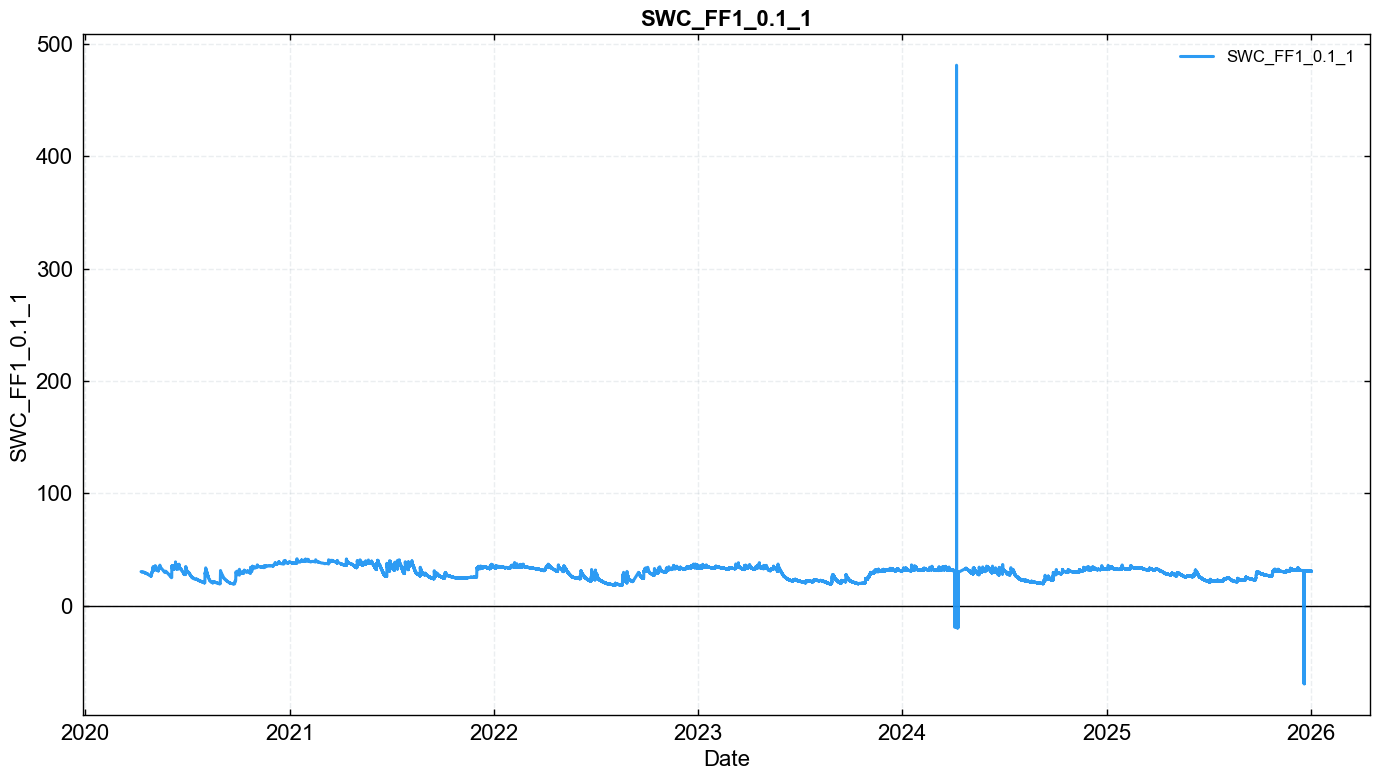

In [12]:
for varname, frame in data_detailed.items():
    dv.plotting.TimeSeries(series=frame[varname]).plot()

## 🔍 Cross-check against the rest of the soil profile
Soil water content has no external reference — no weather service measures the soil at this plot. What it does have is **four other sensors in the same profile**, 5 to 50 cm below the same square metre of forest floor, plus the site's own **precipitation** record. Together those answer the question a single soil sensor cannot answer about itself: *is it still measuring the soil?*

The two failure modes worth separating:

- **it stops reporting** — communication failures, power loss. Loud and easy: gaps and impossible values, which the screening tests below remove.
- **it stops being coupled to the soil** — the soil shrinks away from the prongs in a dry summer, a root grows into the measurement volume, the backfill settles. This one is **quiet**: the series stays inside the physical range, stays smooth, and drifts plausibly. No statistical outlier test can see it. What gives it away is that the sensor no longer *responds*: rain falls, every deeper sensor wets up, and this one does not move.

> **What this can and cannot tell you.** The depths are not replicates — a 5 cm sensor legitimately dries faster, wets first, and swings harder than a 50 cm sensor, so the levels differ and the correlations are far from 1. What is *not* legitimate is a shallow sensor sitting still while the layers underneath it wet up: water reaches 20 cm by passing through 5 cm first. Use the section to *find candidate periods*, then confirm each one against the fieldbook before putting it in `REMOVE_DATES`.

*Sources: the FF1 soil profile (this site) and the screened precipitation product of notebook `30_PRODUCTS/08`.*

In [13]:
def to_30min_mean(series: pd.Series, min_coverage: float = 0.5,
                  max_step: pd.Timedelta = pd.Timedelta('10min')) -> pd.Series:
    """Resample a high-res series to 30MIN means on the end-labelled grid.

    Uses the same end-labelled convention as the database: the period ending at T
    holds the records in (T-30min, T].

    A plain record count cannot decide whether a half hour is well covered here,
    because the raw spacing changes over the record (10MIN before the 2021 logger
    rebuild, 1MIN after) - three records mean full coverage in the first era and
    a 90% gap in the second. Each record is therefore credited with the time it
    represents, i.e. the distance back to the previous record, capped at
    *max_step* so the first record after a long gap cannot claim the whole gap.
    A half hour is returned only when the records present cover at least
    *min_coverage* of it, otherwise NaN - so a gap never masquerades as data.
    """
    if series.empty:
        raise ValueError('to_30min_mean got an empty series')
    spacing = series.index.to_series().diff()
    step = spacing.median()
    if pd.isna(step) or step > pd.Timedelta('30min'):
        raise ValueError(f'cannot resample to 30MIN from a {step} series')
    represented = spacing.clip(upper=max_step).fillna(step)
    grouper = pd.Grouper(freq='30min', label='right', closed='right')
    means = series.groupby(grouper).mean()
    coverage = represented.groupby(grouper).sum() / pd.Timedelta('30min')
    return means.where(coverage >= min_coverage)


def report_blocks(index, label: str, maxgap: str = '1D', note=None):
    """Group a DatetimeIndex of hits into contiguous blocks and print them
    ready to paste into REMOVE_DATES."""
    if len(index) == 0:
        print(f'{label}: none')
        return
    hits = pd.Series(index=pd.DatetimeIndex(index), data=1).sort_index()
    grp = (hits.index.to_series().diff() > pd.Timedelta(maxgap)).cumsum()
    print(f'{label}: {grp.nunique()} period(s)')
    for _, blk in hits.groupby(grp):
        comment = '' if note is None else f'  # {note(blk.index)}'
        print(f"    ['{blk.index[0]:%Y-%m-%d %H:%M:%S}', '{blk.index[-1]:%Y-%m-%d %H:%M:%S}'],{comment}")

#### Negative control
`to_30min_mean` would happily return a series of NaN if handed something that is not high-resolution — silently producing an "empty" comparison that looks like a data gap. Prove it raises instead.

In [14]:
for _bad, _why in [(pd.Series(dtype=float, index=pd.DatetimeIndex([])), 'empty series'),
                   (pd.Series([1.0, 2.0, 3.0],
                              index=pd.date_range('2020-01-01', periods=3, freq='1h')),
                    'already coarser than 30MIN')]:
    try:
        to_30min_mean(_bad)
    except ValueError as e:
        print(f'PASSED - {_why} raises: {e}')
    else:
        raise AssertionError(f'(!) FAILED - to_30min_mean accepted {_why}')

PASSED - empty series raises: to_30min_mean got an empty series
PASSED - already coarser than 30MIN raises: cannot resample to 30MIN from a 0 days 01:00:00 series


### Read the companion depths from the profile file
The other four depths are **not downloaded here**. They are read from the shared raw-profile file `SWC_FF1_PROFILE_RAW_2020-2025.parquet`, written once by [`SWC_FF1_PROFILE_2020-2025.ipynb`](SWC_FF1_PROFILE_2020-2025.ipynb). The five depths are the same raw series in every depth's notebook, so downloading them per notebook meant pulling the same five million-record series from the database five times over; now they are downloaded once and every depth reads the file. Only the columns of the screened period are kept, they are reduced to 30MIN means immediately and the high-resolution frame is dropped again — the cross-check needs half-hourly means, not four more million-record frames in memory.

**The screened variable itself still comes from the live database download above**, not from this file: `StepwiseMeteoScreeningDb` needs the database tags (units, gain, offset, sensor position, data version) that `data_detailed` carries and that a values-only file does not have.

The profile file is **raw and unscreened** — which is exactly why the 5 cm probe's decoupled window (2020-08-01 → 2020-10-24) still has to be masked out of the companion reference below.


In [15]:
# The companion depths are read from the pre-downloaded profile file rather than pulled
# from the database again: they are the same five raw series in every depth's notebook,
# so downloading them once is enough. Produced by SWC_FF1_PROFILE_2020-2025.ipynb.
# The screened variable is NOT taken from here - it comes from the database download
# above, because screening needs the database tags this file does not carry.
_profile_raw = pd.read_parquet(PROFILE_PRODUCT)
assert _profile_raw.index.name == 'TIMESTAMP_END', (
    f'(!) {PROFILE_PRODUCT} is not indexed on TIMESTAMP_END')
_absent = [_v for _v in COMPANION_FIELDS if _v not in _profile_raw.columns]
assert not _absent, (
    f'(!) profile file lacks companion column(s) {_absent} - re-run SWC_FF1_PROFILE_2020-2025.ipynb')
# Trim to exactly the screened period ([START, STOP), STOP excluded) so the cross-check
# cannot silently use a wider record than the one being screened.
_profile_raw = _profile_raw.loc[(_profile_raw.index >= pd.Timestamp(START))
                                & (_profile_raw.index < pd.Timestamp(STOP))]
assert not _profile_raw.empty, (
    '(!) profile file holds no records inside [START, STOP) - is it stale?')
print(f'profile file: {_profile_raw.shape[0]} records, '
      f'{_profile_raw.index[0]} -> {_profile_raw.index[-1]}')

# Target first, then the companions ordered by depth: one 30MIN frame for the whole profile.
prof = pd.DataFrame({FIELD: to_30min_mean(data_detailed[FIELD][FIELD].dropna())})
for _v in COMPANION_FIELDS:
    _series = _profile_raw[_v].dropna()
    if _series.empty:
        print(f'(!) {_v} has no data in this period and is left out of the cross-check.')
        continue
    prof[_v] = to_30min_mean(_series)
prof = prof.sort_index()
COMPANIONS = [c for c in prof.columns if c != FIELD]

del _profile_raw  # the high-res companion frame is not needed again

assert COMPANIONS, '(!) no companion depth available - the cross-check below cannot run'

# The cached companion depths are RAW (unscreened), so the profile mean still contains
# the 5 cm probe's Aug-Oct 2020 decoupled stretch. Mask that one window out of the 5 cm
# companion before it is averaged into the profile mean, so this depth's diagnostics are
# not distorted there. (At 5 cm that probe was the target and its own notebook did not
# need this; here it is a companion.) The target column is never masked.
DECOUPLED_005 = ('2020-08-01', '2020-10-24')
prof_masked = prof.copy()
if 'SWC_FF1_0.05_1' in COMPANIONS:
    _m = (prof_masked.index >= DECOUPLED_005[0]) & (prof_masked.index < DECOUPLED_005[1])
    prof_masked.loc[_m, 'SWC_FF1_0.05_1'] = np.nan
    print(f'masked 5 cm decoupled window {DECOUPLED_005}: {int(_m.sum())} half-hours '
          f'excluded from the companion mean')

print(f'profile frame: {prof.shape[0]} half-hours, {prof.index[0]} -> {prof.index[-1]}')
print(f'target: {FIELD} | companions: {COMPANIONS}')

profile file: 2509501 records, 2020-04-10 15:00:00 -> 2026-01-01 00:00:00
masked 5 cm decoupled window ('2020-08-01', '2020-10-24'): 4032 half-hours excluded from the companion mean
profile frame: 100387 half-hours, 2020-04-10 15:00:00 -> 2026-01-01 00:00:00
target: SWC_FF1_0.1_1 | companions: ['SWC_FF1_0.05_1', 'SWC_FF1_0.2_1', 'SWC_FF1_0.3_1', 'SWC_FF1_0.5_1']


### Level, coverage and correlation
First the plain description: how much data each sensor has, where it sits, and how strongly the depths move together. Correlations between depths are expected to be **high but not near-perfect** (r ≈ 0.7-0.9 on daily means) and to *decrease with depth separation* — the 5 cm and 50 cm sensors measure genuinely different things.

In [16]:
print('data coverage per year (fraction of 30MIN periods with a value):')
display(prof.notna().groupby(prof.index.year).mean().round(3))

print('\nlevel and spread over the whole period [% VWC]:')
display(prof.describe().round(2))

print('\ncorrelation of daily means:')
display(prof.resample('D').mean().corr().round(3))

data coverage per year (fraction of 30MIN periods with a value):


,SWC_FF1_0.1_1,SWC_FF1_0.05_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1
TIMESTAMP_END,,,,,
2020,1.000,1.000,1.000,1.000,1.000
2021,0.977,0.977,0.977,0.977,0.977
2022,0.972,0.972,0.972,0.972,0.972
2023,0.998,0.998,0.998,0.998,0.998
2024,0.950,0.948,0.951,0.272,0.953
2025,1.000,1.000,1.000,0.828,1.000
2026,1.000,1.000,1.000,1.000,1.000



level and spread over the whole period [% VWC]:


,SWC_FF1_0.1_1,SWC_FF1_0.05_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1
count,98583.00,98538.00,98585.00,83666.00,98624.00
mean,29.77,29.52,31.23,27.15,24.12
std,5.26,5.45,4.11,3.51,2.77
min,18.20,-16.90,20.37,19.91,3.96
25%,25.29,24.67,27.77,23.65,20.71
50%,31.11,30.64,32.83,28.48,25.35
75%,33.53,34.08,34.27,29.51,26.25
max,54.26,39.71,39.03,36.41,31.75



correlation of daily means:


,SWC_FF1_0.1_1,SWC_FF1_0.05_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1
SWC_FF1_0.1_1,1.000,0.897,0.928,0.754,0.849
SWC_FF1_0.05_1,0.897,1.000,0.893,0.716,0.847
SWC_FF1_0.2_1,0.928,0.893,1.000,0.891,0.879
SWC_FF1_0.3_1,0.754,0.716,0.891,1.000,0.853
SWC_FF1_0.5_1,0.849,0.847,0.879,0.853,1.000


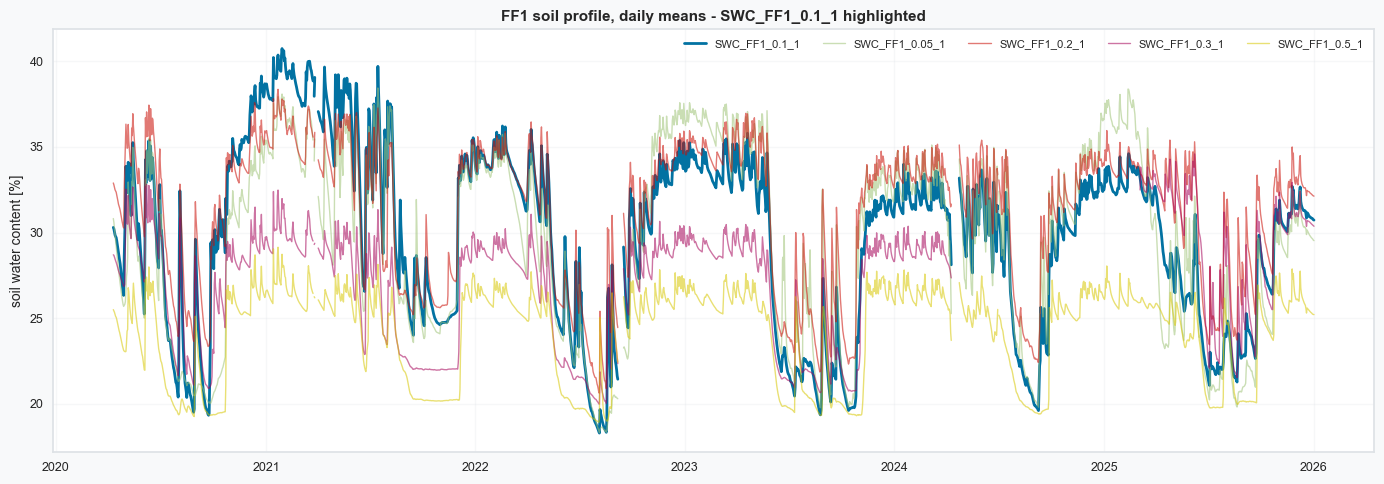

In [17]:
_daily = prof.resample('D').mean()            # raw profile, for the plot below
_daily_m = prof_masked.resample('D').mean()   # 5 cm decoupled window masked, for diagnostics
fig, ax = plt.subplots(figsize=(14, 5))
for _c in prof.columns:
    _lw, _alpha = (2.0, 1.0) if _c == FIELD else (1.0, .55)
    ax.plot(_daily.index, _daily[_c], label=_c, lw=_lw, alpha=_alpha)
ax.set_ylabel('soil water content [%]')
ax.set_title(f'FF1 soil profile, daily means - {FIELD} highlighted')
ax.legend(ncol=len(prof.columns), fontsize=8)
plt.tight_layout()
plt.show()

### Does the target still move with the profile?
Levels differ by depth, so compare **changes** rather than values: the daily change of the target against the daily change of the rest of the profile, correlated in a rolling 30-day window. A well-coupled sensor keeps this high (r ≈ 0.8-0.9); a sensor that has lost contact with the soil keeps producing smooth, in-range values whose *changes* have nothing to do with what the soil is doing, and the rolling correlation collapses.

This is the diagnostic that exposed the 5 cm probe's Aug-Oct 2020 decoupling. **At 10 cm it finds nothing:** the rolling correlation stays at or above 0.30 in every window across all six years (yearly minima 0.30-0.60), so there is no decoupled stretch to remove here. The check is run all the same — it is the only thing that can catch a quietly decoupled probe, and a null result is the evidence that this depth stayed coupled.

> The 5 cm decoupling window (2020-08-01 → 2020-10-24) is masked out of the companion mean before this correlation is computed, because the cached companion depths are **raw/unscreened** and would otherwise drag the profile mean during exactly that stretch.

rolling 30-day correlation of daily increments, target vs profile mean:


,count,mean,std,min,25%,50%,75%,max
TIMESTAMP_END,,,,,,,,
2020,246.0,0.84,0.13,0.30,0.71,0.88,0.95,0.99
2021,365.0,0.83,0.16,0.34,0.79,0.88,0.95,0.99
2022,365.0,0.93,0.07,0.54,0.91,0.96,0.98,1.00
2023,365.0,0.93,0.05,0.35,0.90,0.94,0.96,1.00
2024,343.0,0.93,0.07,0.60,0.92,0.96,0.98,1.00
2025,365.0,0.81,0.14,0.33,0.72,0.85,0.91,0.99
2026,1.0,0.99,NaN,0.99,0.99,0.99,0.99,0.99


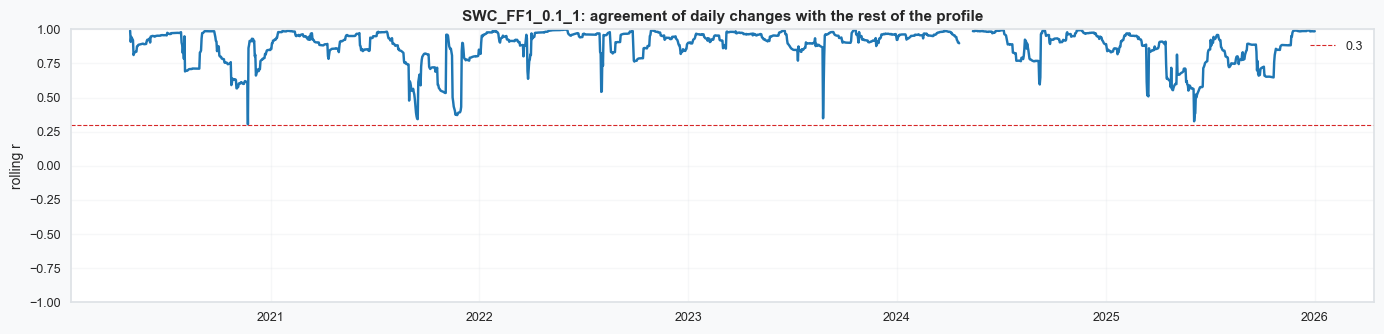

ROLLING AGREEMENT BELOW 0.3: none


In [18]:
_d_target = _daily_m[FIELD].diff()
_d_others = _daily_m[COMPANIONS].mean(axis=1).diff()
rollcorr = _d_target.rolling(30, min_periods=20).corr(_d_others)

print('rolling 30-day correlation of daily increments, target vs profile mean:')
display(rollcorr.groupby(rollcorr.index.year).describe().round(2))

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(rollcorr.index, rollcorr, color='tab:blue')
ax.axhline(0.3, color='tab:red', lw=.8, ls='--', label='0.3')
ax.set_ylim(-1, 1)
ax.set_ylabel('rolling r')
ax.set_title(f'{FIELD}: agreement of daily changes with the rest of the profile')
ax.legend()
plt.tight_layout()
plt.show()

report_blocks(rollcorr[rollcorr < 0.3].index, 'ROLLING AGREEMENT BELOW 0.3', maxgap='3D',
              note=lambda ix: f'{len(ix)} day(s)')

### Does the target still respond to rain?
The sharpest test for the shallowest sensor. For every day with more than 10 mm of precipitation, take the rise of each depth's daily mean over the following two days, and divide the target's rise by the profile mean's. A shallow sensor should give a **ratio at or above 1** — water arrives at 5 cm first. A ratio near **0** while the deeper sensors rise by several percent VWC is physically impossible and means the probe is no longer coupled to the soil.

The summer table is the one to read: that is when soil shrinkage opens gaps around the prongs.

In [19]:
prec = pd.read_parquet(PREC_PRODUCT)[PREC_COL]
prec.index = prec.index + pd.Timedelta('15min')  # TIMESTAMP_MID -> TIMESTAMP_END, as used here
_shared = prof.index.intersection(prec.index)
assert len(_shared) > 0.5 * len(prof), (
    '(!) precipitation product does not line up with the profile - check the timestamp shift')
print(f'precipitation: {prec.index[0]} -> {prec.index[-1]}, '
      f'{len(_shared) / len(prof) * 100:.1f}% of the profile period covered')

_dprec = prec.reindex(prof.index).resample('D').sum(min_count=40)
_events = _dprec[_dprec > 10].index

_rows = []
for _day in _events:
    _before = _daily_m.loc[:_day - pd.Timedelta('1D')].tail(1)
    _after = _daily_m.loc[_day:_day + pd.Timedelta('2D')]
    if _before.empty or _after.empty:
        continue
    _resp = _after.max() - _before.iloc[0]
    _resp['PREC'] = _dprec.loc[_day]
    _rows.append(_resp.rename(_day))
resp = pd.DataFrame(_rows)
resp['RATIO'] = resp[FIELD] / resp[COMPANIONS].mean(axis=1)
print(f'\n{len(resp)} rain events > 10 mm/day in the screened period')

print('\nmedian rise per depth [% VWC] after a > 10 mm day, per year:')
display(resp.groupby(resp.index.year).median().round(2))

print('\nmedian response ratio (target / profile mean), all events and summer only:')
_summer = resp[resp.index.month.isin([7, 8, 9, 10])]
display(pd.DataFrame({'all events': resp['RATIO'].groupby(resp.index.year).median(),
                      'Jul-Oct': _summer['RATIO'].groupby(_summer.index.year).median(),
                      'n events': resp['RATIO'].groupby(resp.index.year).size()}).round(2))

precipitation: 2004-01-01 00:30:00 -> 2026-01-01 00:00:00, 100.0% of the profile period covered

198 rain events > 10 mm/day in the screened period

median rise per depth [% VWC] after a > 10 mm day, per year:


,SWC_FF1_0.1_1,SWC_FF1_0.05_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1,PREC,RATIO
2020,2.95,1.69,2.11,2.06,0.69,14.4,1.21
2021,2.00,1.95,1.62,1.67,1.21,13.8,1.19
2022,1.57,1.17,1.45,1.32,1.43,13.9,1.18
2023,1.31,2.93,1.44,0.70,0.29,14.6,0.81
2024,1.73,2.32,1.92,0.94,0.59,15.5,1.15
2025,1.42,2.07,2.25,3.04,1.09,15.7,0.68



median response ratio (target / profile mean), all events and summer only:


,all events,Jul-Oct,n events
2020,1.21,1.39,20
2021,1.19,1.47,36
2022,1.18,1.15,30
2023,0.81,0.43,32
2024,1.15,0.98,39
2025,0.68,0.60,41


### The sandwich test: did the layers above and below wet up without this one?

The profile-mean ratio above can be dragged around by the deeper sensors — the 0.3 m probe was relocated 40 cm down the slope in March 2025, and the 0.5 m probe barely responds to summer rain at all — so a low ratio does not by itself convict the target. The sharper question for a **10 cm** probe uses only its two immediate neighbours: **did 5 cm (above) and 20 cm (below) both wet up while 10 cm did not?** Water cannot reach 20 cm without passing 10 cm, so that pattern is physically impossible for a probe still coupled to the soil, whatever the deeper sensors are doing.

The same cell separates the innocent case: when **both shallow sensors are flat together** while only the deeper ones rise, that is the signature of preferential / macropore bypass flow in dry soil — a real forest-soil phenomenon — and says nothing about this probe in particular.

This scan is what turned the 2025 ratio dip from a presumed reference artefact into the documented finding in *Known limitation* at the end of this notebook. It flags 2023 and 2025 and nothing else.

In [20]:
# Compare the target only against its two IMMEDIATE neighbours - the one comparison physics
# constrains, since water cannot skip a layer on its way down.
_UP, _DN = f'SWC_{PROFILE}_0.05_{REPL}', f'SWC_{PROFILE}_0.2_{REPL}'
_bracket = [c for c in (_UP, _DN) if c in _daily_m.columns]
assert len(_bracket) == 2, '(!) the sandwich scan needs both the 0.05 and 0.2 companions'

_rows = []
for _day in _events:
    _b = _daily_m.loc[:_day - pd.Timedelta('1D')].tail(1)
    _a = _daily_m.loc[_day:_day + pd.Timedelta('2D')]
    if _b.empty or _a.empty:
        continue
    _r = _a.max() - _b.iloc[0]
    _rows.append(pd.Series({'PREC': _dprec.loc[_day], _UP: _r[_UP],
                            FIELD: _r[FIELD], _DN: _r[_DN]}, name=_day))
sand = pd.DataFrame(_rows)
sand['BRACKET_RATIO'] = sand[FIELD] / sand[_bracket].mean(axis=1)

# Sandwich: both neighbours clearly wet up, the target rises less than a third of the smaller
# of the two. This is the pattern that cannot happen if the probe is coupled to the soil.
sand['SANDWICH'] = ((sand[_UP] > 2.0) & (sand[_DN] > 2.0)
                    & (sand[FIELD] < 0.35 * sand[_bracket].min(axis=1)))
# Both shallow sensors flat together while the deeper ones rise: preferential/macropore
# bypass flow in dry soil, NOT a fault of this probe.
sand['BOTH_SHALLOW_FLAT'] = (sand[_UP] < 1.0) & (sand[FIELD] < 1.0) & (sand[_DN] > 2.0)

print('per year - sandwich events (target alone fails) vs both-shallow-flat (bypass):')
display(sand.groupby(sand.index.year)[['SANDWICH', 'BOTH_SHALLOW_FLAT']].sum())

print('\nSANDWICH events - the target alone failed to respond:')
display(sand[sand['SANDWICH']].round(2))

print('\nBOTH-SHALLOW-FLAT events - bypass signature, exonerates this probe:')
display(sand[sand['BOTH_SHALLOW_FLAT']].round(2))

print('\nmonthly amplitude ratio amp(target)/amp(0.2), Apr-Oct (a muted probe sits well below 1):')
_amp = _daily_m.resample('ME').agg(lambda x: x.max() - x.min())
_ar = _amp[FIELD] / _amp[_DN]
_ar = _ar[_ar.index.month.isin(range(4, 11))]
display(_ar.groupby([_ar.index.year, _ar.index.month]).first().unstack().round(2))

print('\n(Sandwich events are CANDIDATES. At this depth they were adjudicated and KEPT -')
print(' see the closing note "Known limitation". Judge by the neighbours, not the profile mean.)')

per year - sandwich events (target alone fails) vs both-shallow-flat (bypass):


,SANDWICH,BOTH_SHALLOW_FLAT
2020,0,0
2021,0,0
2022,0,0
2023,5,0
2024,0,0
2025,7,2



SANDWICH events - the target alone failed to respond:


,PREC,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.2_1,BRACKET_RATIO,SANDWICH,BOTH_SHALLOW_FLAT
2023-07-24,13.6,7.23,1.22,5.87,0.19,True,False
2023-07-25,17.0,7.23,1.37,5.43,0.22,True,False
2023-07-26,18.1,6.56,1.25,5.10,0.21,True,False
2023-09-13,41.7,7.20,2.28,7.52,0.31,True,False
2023-10-24,10.2,4.36,0.68,2.42,0.20,True,False
2025-04-23,13.4,4.81,0.57,2.75,0.15,True,False
2025-05-20,18.5,6.99,0.08,5.71,0.01,True,False
2025-05-21,10.3,6.88,0.75,5.48,0.12,True,False
2025-07-26,10.8,5.38,1.48,6.58,0.25,True,False
2025-07-27,25.3,6.11,2.06,6.79,0.32,True,False



BOTH-SHALLOW-FLAT events - bypass signature, exonerates this probe:


,PREC,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.2_1,BRACKET_RATIO,SANDWICH,BOTH_SHALLOW_FLAT
2025-08-28,12.2,0.29,0.15,2.23,0.12,False,True
2025-08-29,12.1,0.29,0.12,2.50,0.09,False,True



monthly amplitude ratio amp(target)/amp(0.2), Apr-Oct (a muted probe sits well below 1):


TIMESTAMP_END,4,5,6,7,8,9,10
TIMESTAMP_END,,,,,,,
2020,1.14,1.34,1.32,1.07,1.41,1.36,1.15
2021,1.47,1.16,1.18,1.15,1.23,1.41,0.73
2022,0.99,1.02,1.29,1.50,0.95,1.15,1.27
2023,1.08,0.87,1.24,0.32,0.75,0.77,0.56
2024,1.40,1.04,1.09,0.98,0.97,0.92,1.03
2025,1.19,0.64,0.83,0.34,0.43,0.89,0.81



(Sandwich events are CANDIDATES. At this depth they were adjudicated and KEPT -
 see the closing note "Known limitation". Judge by the neighbours, not the profile mean.)


### Candidate periods for `REMOVE_DATES`
Four scans, each for a different failure mode. All of them produce **candidates only** — check each against the fieldbook and against the plots above before removing anything.

In [21]:
_target_hires = data_detailed[FIELD][FIELD].dropna()

report_blocks(_target_hires[(_target_hires < SWC_MIN) | (_target_hires > SWC_MAX)].index,
              f'OUTSIDE THE PHYSICAL RANGE [{SWC_MIN}, {SWC_MAX}] %', maxgap='1D',
              note=lambda ix: f'{len(ix)} record(s)')

_cov = prof[FIELD].notna().resample('D').mean()
report_blocks(_cov[_cov < 0.9].index, 'DAILY COVERAGE BELOW 90%', maxgap='2D',
              note=lambda ix: f'{len(ix)} day(s)')

report_blocks(rollcorr[rollcorr < 0.3].index, 'NOT MOVING WITH THE PROFILE (rolling r < 0.3)',
              maxgap='3D', note=lambda ix: f'{len(ix)} day(s)')

# A stuck sensor repeats one value. Runs are measured in *time*, not in records,
# because a record means ten minutes in the early era and one minute in the late one.
# Stored precision also changed: until the logger software update of 21 Apr 2020 the
# values arrived in steps of 0.1%, so during a slow dry-down they legitimately hold the
# same rounded value for hours. The threshold below is therefore loose, and the maxima
# printed with it are the more informative numbers.
_runs = (_target_hires != _target_hires.shift()).cumsum()
_spans = _target_hires.groupby(_runs).apply(lambda x: x.index[-1] - x.index[0])
_ends = _target_hires.groupby(_runs).apply(lambda x: x.index[-1])
_sizes = _target_hires.groupby(_runs).size()
_stuck = _spans[_spans >= pd.Timedelta('24h')]
print(f'IDENTICAL-VALUE RUNS LASTING >= 24 h: {len(_stuck)}')
for _g in _stuck.index:
    print(f"    ['{_ends.loc[_g] - _spans.loc[_g]:%Y-%m-%d %H:%M:%S}', "
          f"'{_ends.loc[_g]:%Y-%m-%d %H:%M:%S}'],  # {_sizes.loc[_g]} identical records")
for _label, _mask in [('whole record', _spans.notna()),
                      ('1MIN era only', _ends > pd.Timestamp('2021-03-27'))]:
    _sub = _spans[_mask]
    print(f'   longest identical-value run, {_label}: {_sub.max()} '
          f'(ending {_ends.loc[_sub.idxmax()]})')

print('\n(Copy any confirmed period into REMOVE_DATES below. Check the fieldbook first.)')

OUTSIDE THE PHYSICAL RANGE [0, 60] %: 3 period(s)
    ['2024-04-03 10:32:00', '2024-04-04 11:55:00'],  # 6 record(s)
    ['2024-04-05 20:52:00', '2024-04-09 07:23:00'],  # 15 record(s)
    ['2025-12-18 17:45:00', '2025-12-19 10:39:00'],  # 7 record(s)
DAILY COVERAGE BELOW 90%: 6 period(s)
    ['2021-03-24 00:00:00', '2021-04-02 00:00:00'],  # 10 day(s)
    ['2022-09-06 00:00:00', '2022-09-16 00:00:00'],  # 11 day(s)
    ['2023-06-15 00:00:00', '2023-06-15 00:00:00'],  # 1 day(s)
    ['2024-04-04 00:00:00', '2024-04-23 00:00:00'],  # 19 day(s)
    ['2024-06-29 00:00:00', '2024-07-01 00:00:00'],  # 3 day(s)
    ['2024-10-16 00:00:00', '2024-10-16 00:00:00'],  # 1 day(s)
NOT MOVING WITH THE PROFILE (rolling r < 0.3): none
IDENTICAL-VALUE RUNS LASTING >= 24 h: 1
    ['2020-04-13 14:10:00', '2020-04-14 16:10:00'],  # 157 identical records
   longest identical-value run, whole record: 1 days 02:00:00 (ending 2020-04-14 16:10:00)
   longest identical-value run, 1MIN era only: 0 days 00:06:00 

### Adjudicate the candidates against the fieldbook
A candidate period means nothing until it is matched against what happened at the site. The GIN
fieldbook export is read here directly, so the adjudication written up below can be re-run and
challenged rather than taken on trust.

Filtering on the SWC device tags alone would miss most of it: the entries that explain these periods
are power-supply and logger entries carrying no soil device at all. The filter therefore also takes
anything at this profile's location, its logger/DAQ, or a free-text mention of soil, power, logger
or SDI-12.

In [22]:
import html
import re
from pathlib import Path

_fb = pd.read_csv(FIELDBOOK, encoding='utf-8-sig')
_fb.columns = [c.strip() for c in _fb.columns]
_fb['date'] = pd.to_datetime(_fb['Date'], format='%d.%m.%Y', errors='coerce')
assert _fb['date'].notna().all(), '(!) unparsed dates in the fieldbook - check the date format'


# --- Fieldbook redaction --------------------------------------------------------------------
# The GIN fieldbook is also a personnel record: its entries name the people who did the work, and
# this notebook renders to a public page. Those names are replaced here, at the single point every
# fieldbook string passes through on its way to being printed - so a print site added later is
# covered without anyone having to remember it.
#
# The map lives beside the export, OUTSIDE this repository, so the repo never carries a real name.
# Its path is derived from FIELDBOOK rather than written out again, so the two cannot drift apart.
# Pseudonyms are stable and append-only, so re-running this notebook reproduces the same text.
REDACT_MAP = Path(FIELDBOOK).with_name('redact_names.csv')


def load_redactions(path=None) -> dict:
    """Load the name -> pseudonym map used to redact the fieldbook.

    Raises FileNotFoundError if the map is missing. That is the point: a missing map has to stop
    the notebook, because the alternative - carrying on with the redaction quietly disabled -
    prints real names into a published page and looks exactly like success.
    """
    path = REDACT_MAP if path is None else Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"the fieldbook redaction map is missing: {path}. Without it the names the fieldbook "
            f"records would print unredacted. Restore the file rather than skipping this.")
    tab = pd.read_csv(path, encoding='utf-8')
    missing = {'name', 'pseudonym'}.difference(tab.columns)
    if missing:
        raise ValueError(f"{path}: missing column(s) {sorted(missing)}.")
    pairs = {str(n).strip(): str(p).strip()
             for n, p in zip(tab['name'], tab['pseudonym']) if str(n).strip()}
    if not pairs:
        raise ValueError(f"{path}: holds no usable name -> pseudonym pairs.")
    return pairs


REDACTIONS = load_redactions()

# Longest surface form first, which is not cosmetic: the map holds both a bare surname and a
# double-barrelled one that starts with it ('Lovelace' and 'Lovelace-Byron', to use names that
# belong to nobody here), and replacing the short form first would corrupt the long one. The
# boundaries are lookarounds rather than \b because some forms end in an initial ('A. Lovelace'),
# where \b does not match. Matching is case-sensitive - these are capitalised names, and a case-insensitive pass
# would eat ordinary words.
_REDACT_RX = re.compile(r'(?<!\w)(' + '|'.join(re.escape(n) for n in
                                               sorted(REDACTIONS, key=len, reverse=True))
                        + r')(?!\w)')


def redact_people(s) -> str:
    """Replace every mapped name in a fieldbook string with its stable pseudonym."""
    return _REDACT_RX.sub(lambda m: REDACTIONS[m.group(1)], str(s))


# --- The unknown-name net ---------------------------------------------------------------------
# The map can only redact the names it already knows; this catches the ones it does not. After
# redaction, a token sitting in one of the two shapes that actually carry names - the author
# parenthesis the entries are signed with, and byline phrases such as 'with X' or 'durch X' - and
# that is neither a known technical term nor an all-caps device code is a candidate name.
#
# Both shapes were measured against the whole export before being trusted: together they leave 54
# distinct tokens on it, every one of them technical. A third shape, any capitalised pair, was
# tried and REJECTED - it leaves 560 distinct tokens, nearly all sentence starters and device
# names, which would bury the signal and train everyone to ignore the check.
#
# Candidates are never printed. An unmapped token is most likely a real name, and an exception
# message is stored in a notebook exactly like any other output - so the list is written beside
# the map and only the count is shown here.
ALLOW_LIST = Path(FIELDBOOK).with_name('redact_allow.csv')
UNMAPPED_REPORT = Path(FIELDBOOK).with_name('redact_unmapped.txt')
_NAME_TOKEN = r"[A-ZÄÖÜ][\wÄÖÜäöüß'-]{1,20}"
# A person is up to three capitalised words ('Ada Marie Lovelace'), and a parenthesis can list
# several of them. Matching only comma-separated single tokens was the first attempt, and it
# quietly matched almost nothing - '(Ada Lovelace)' is separated by a space, not a comma - so the
# net passed by looking at nothing at all. The positive control below is what caught that, which
# is the reason it is here rather than in a test somewhere else.
_NAME_UNIT = _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r'){0,2}'
_NAME_SHAPES = (
    re.compile(r'\((' + _NAME_UNIT + r'(?:\s*[,+&]\s*' + _NAME_UNIT + r')*)\s*'
               r'(?:\d{1,2}\.\d{1,2}\.\d{4})?\)'),
    re.compile(r'(?:with|by|durch|von|gemaess)\s+('
               + _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r')?)'),
)


def audit_unmapped_names(texts, label='fieldbook', write_report: bool = True) -> int:
    """Raise if any name-shaped token survived redaction.

    A newer export can name someone the map has never seen. Stopping here is the point: the
    alternative is that person's name printing into a page that gets published. Returns 0 so the
    call reads as a check rather than as something that produces a value.
    """
    allow = set(pd.read_csv(ALLOW_LIST, encoding='utf-8')['term'].astype(str).str.strip())
    found = {}
    for _t in texts:
        for _rx in _NAME_SHAPES:
            for _m in _rx.finditer(str(_t)):
                for _tok in re.findall(_NAME_TOKEN, _m.group(1)):
                    if _tok.isupper() or any(ch.isdigit() for ch in _tok) or _tok in allow:
                        continue
                    found[_tok] = found.get(_tok, 0) + 1
    if found:
        if write_report:
            UNMAPPED_REPORT.write_text(
                '\n'.join(f'{n}\t{t}' for t, n in sorted(found.items(), key=lambda kv: -kv[1])),
                encoding='utf-8')
        raise ValueError(
            f"{label}: {len(found)} name-shaped token(s) survived redaction. They are deliberately "
            f"NOT shown here - see {UNMAPPED_REPORT}. Add the people to redact_names.csv and the "
            f"technical terms to redact_allow.csv, then re-run.")
    print(f"  {label}: no unmapped name-shaped tokens ({len(allow)} allowlisted terms)")
    return 0

# The net is only worth having if it fires. 'Ada Lovelace' is nobody at this site, so the control
# can spell her out without disclosing anything - and it writes no report, so the real one is not
# overwritten by a test.
try:
    audit_unmapped_names(['12.05.2019 (Ada Lovelace) replaced the logger battery'],
                         'positive control', write_report=False)
except ValueError:
    print('  OK, the unknown-name net fired on a name that is not in the map')
else:
    raise AssertionError('(!) the unknown-name net did not fire on an unmapped name - it is broken.')


# The redaction is only worth having if it fires, so it is checked on a name from
# the map itself. Neither this assertion nor anything it prints may carry a real
# name, so the probe is compared against the map rather than shown.
_probe = next(iter(REDACTIONS))
assert _probe not in redact_people(f'written by {_probe}'), \
    '(!) redact_people left a mapped name in the text - the redaction is broken.'
print(f'fieldbook redaction: {len(REDACTIONS):,} surface forms loaded')


def _plaintext(s):
    """GIN stores the entry body as HTML; strip the tags and entities, and redact the names.

    Redaction happens here rather than at each print site, so that no caller can obtain the raw
    text by accident.
    """
    flat = re.sub(r'\s+', ' ',
                  html.unescape(re.sub(r'<[^>]+>', ' ', str(s))).replace('\xa0', ' ')).strip()
    return redact_people(flat)


_fb['text'] = _fb['Text'].map(_plaintext)
audit_unmapped_names(_fb['text'], 'fieldbook entries')
_mask = (_fb['Operation Tag'].astype(str).str.contains(r'SWC|iDL_FF1|iDAQ_FF1', case=False, na=False)
         | _fb['Location'].astype(str).str.contains(PROFILE, case=False, na=False)
         | _fb['text'].str.contains(r'soil|SWC|Teros|SDI|power|logger', case=False, na=False))
fb = (_fb[_mask & _fb['date'].between(START, STOP)]
      .drop_duplicates(subset=['date', 'Event Tag', 'Text'])
      .sort_values('date'))
assert len(fb) > 0, '(!) no fieldbook entries matched - has the export format changed?'
print(f'fieldbook: {len(_fb)} entries total, '
      f'{len(fb)} relevant to {PROFILE} within the screened period')


def fieldbook_near(start, stop=None, days: int = 3, maxchars: int = 220):
    """Print the fieldbook entries within *days* of a period."""
    start = pd.Timestamp(start)
    stop = pd.Timestamp(stop) if stop is not None else start
    hits = fb[fb['date'].between(start - pd.Timedelta(days=days), stop + pd.Timedelta(days=days))]
    if hits.empty:
        print(f'   (no fieldbook entry within +/-{days} days)')
        return
    for _, r in hits.iterrows():
        print(f"   {r['date']:%Y-%m-%d} {r['Event Tag']:<12s} {r['text'][:maxchars]}")

fieldbook: 2102 entries total, 129 relevant to FF1 within the screened period


In [23]:
# One entry per candidate period found by the scans above. Rebuilt from THIS depth's own
# scan output (0.1 m) - not carried over from 0.05. It is the record of what was adjudicated.
CANDIDATES = [
    ('2024-04-03', '2024-04-04', 'out-of-range values (SDI-12 bus failure)'),
    ('2024-04-05', '2024-04-09', 'out-of-range values incl. the +481% read'),
    ('2025-12-18', '2025-12-19', 'out-of-range values (logger-program uploads)'),
    ('2021-03-24', '2021-04-02', 'coverage gap (logger rebuild)'),
    ('2022-09-06', '2022-09-16', 'coverage gap (FF1 power supply)'),
    ('2023-06-15', '2023-06-15', 'coverage gap (FF1 power incident)'),
    ('2024-04-04', '2024-04-23', 'coverage gap (SDI-12 bus failure)'),
    ('2024-06-29', '2024-07-01', 'coverage gap (station-wide, unexplained)'),
    ('2024-10-16', '2024-10-16', 'coverage gap (station-wide, unexplained)'),
    ('2020-04-13', '2020-04-14', 'identical-value run >= 24 h (0.1% precision era)'),
    ('2023-07-24', '2023-10-24', 'muted wetting response, 5 sandwich events - kept, see note'),
    ('2025-04-23', '2025-09-21', 'muted wetting response, 7 sandwich events - kept, see note'),
]
for _start, _stop, _why in CANDIDATES:
    print(f'\n--- {_start} -> {_stop}  ({_why})')
    fieldbook_near(_start, _stop, days=3)


--- 2024-04-03 -> 2024-04-04  (out-of-range values (SDI-12 bus failure))
   2024-04-02 HW_MOD       Worked on the deviceRepowered the sonic via ioLogik. This resolved the issue.

--- 2024-04-05 -> 2024-04-09  (out-of-range values incl. the +481% read)
   2024-04-02 HW_MOD       Worked on the deviceRepowered the sonic via ioLogik. This resolved the issue.

--- 2025-12-18 -> 2025-12-19  (out-of-range values (logger-program uploads))
   2025-12-18 SW_MOD       Remotly uploaded new loggerprogram to the FF1 meteo logger
   2025-12-19 SW_MOD       Remotly updated a new loggerprogram to fix the windvane issue which existed for a long time. The last update didn't fix the issue as expected. https://gitlab.ethz.ch/gl/ch-lae_idl_ff1_0_1/-/tree/300b088aeddd5d3b3106c567b

--- 2021-03-24 -> 2021-04-02  (coverage gap (logger rebuild))
   2021-03-24 HW_MOD       Installed new box with datalogger und multiplexer
   2021-03-24 TRASHED      Device trashed
   2021-03-24 HW_MOD       Shutdown the FF1 logg

#### How to read the candidate list

The outcome for `SWC_FF1_0.1_1`, read off the cell above:

- **Out of physical range** — **28 records**, and this is where 0.1 m differs from every other depth. 27 are the familiar failed-read sentinels: isolated single-minute values at fixed negative levels (−14.2, −19.1 … −69.56), the same fixed numbers that appear on the other depths at the same minutes when an SDI-12 read fails (the CR1000 firmware predates NaN support — fieldbook 2020-04-10). The 28th is a single **+481.04% VWC** at **2024-04-06 18:29**, sitting between two ordinary 30.5% readings one minute either side. It is the *only* value above 60 in the whole five-sensor profile (the other four maxima are 39-41%), so it is caught by the **upper** absolute limit — decorative at 0.05, load-bearing here. All 28 fall in the 1MIN era and in two documented clusters: the **April 2024 SDI-12 bus failure** (2024-04-03 → 2024-04-09, 21 records incl. the +481) and the **two remote logger-program uploads of 18-19 Dec 2025** (7 records, identical timing on all five depths — a logger-side event). Note what the adjudication cell actually prints: the Dec 2025 uploads land on exactly those two dates, but the entry naming the bus failure is dated **23 Apr 2024** (“Unplugged the device … caused an interruption of the SDI12 communication of all sensors at the same port”), so it surfaces against the *coverage* candidate that ends that day, not within ±3 days of the out-of-range records themselves — whose own ±3-day window holds only an unrelated sonic entry. They are removed **without hand-adjudication**, by two mechanisms: **21 of the 28** sit in the stray 2/3/5/6-minute frequency groups the bus failure produced and diive discards them before screening starts; the remaining **7** (6 negatives + the +481) reach the **absolute-limits test**. Removing them costs no half-hourly value: each is an isolated minute inside an otherwise complete half hour — the +481's half hour keeps 18 of its 19 records and its 30MIN mean falls from a contaminated 54.26 back to 30.55.
- **Coverage below 90%** — six periods, all matching profile-wide events and all already missing (gaps need no removal): the 2021-03 logger rebuild, the Sep 2022 FF1 power-supply failure, the 15 Jun 2023 FF1 power incident, the April 2024 bus failure (ended by unplugging the failing 0.3 m probe on 23 Apr), and the two station-wide outages with **no** fieldbook entry within ±3 days — **2024-06-29 → 2024-07-01** (44 h, the same gap notebook `30_PRODUCTS/08` found in precipitation) and **2024-10-16** (8 h).
- **Not moving with the profile** — **none**. The rolling 30-day agreement of daily increments with the rest of the profile never drops below 0.30 (yearly minima 0.30-0.60), so unlike the 5 cm probe this depth shows **no decoupling** anywhere in the record. The 5 cm decoupled window is masked out of the companion mean first (the cached companions are raw), so this null result is real and not an artefact of a distorted reference.
- **Identical-value runs** — one run reaches 24 h (**2020-04-13 14:10 → 2020-04-14 16:10**, 157 identical records ≈ 26 h), and it falls inside the **11 days before 2020-04-21** when values arrived in steps of exactly 0.1% (20 distinct values in the first 1567 records). That ends with the fieldbook entry of 2020-04-21, *"New datalogger software with two byte precision for the soil profile measurement"*: from that afternoon on the values carry full float precision (332 distinct in the next 359 records) and the long holds stop. A storage-resolution artefact, not a stuck sensor — the values are usable, just coarse. In the 1MIN era no value ever repeats for more than **6 minutes**.

- **Muted wetting response in 2023 and 2025 (the sandwich scan)** — the one finding that is *not* covered by any of the four scans above, and the reason the sandwich cell exists. In 2023 (5 events) and 2025 (7 events) this probe repeatedly failed to respond to rain **while the layers directly above and below it both wet up by 5-7% VWC**. Water cannot reach 20 cm without passing 10 cm, so this is not a reference artefact. The extreme case is **2025-05-20**: at hourly resolution 0.05 m rises 23.5 → 29.7% and 0.2 m rises 28.7 → 34.5% over the same two hours, while 0.1 m moves from 25.37 to 25.39 — **0.02%**. Saturation is ruled out (the daily mean sat at 25.40% against an in-range record maximum of 41.75%, ~15 points of headroom). **Kept, not removed** — see the closing note *Known limitation* for the full adjudication.

Note what the sandwich scan also **exonerates**: on 2025-08-28/29 *both* shallow sensors are flat together (0.05 +0.29, 0.1 +0.15) while only 0.2 and 0.3 rise. Two simultaneous shallow-sensor faults are unlikely; that is the signature of preferential / macropore bypass flow in dry soil, and it says nothing about this probe. The same holds for 2025-07-07/08 and 2025-09-01.

The **rolling agreement stays above 0.30 throughout**, in every year — day to day this probe still tracks the profile; it is specifically the *amplitude of large wetting fronts* that is muted, and only in two dry summers. **Nothing here needs a manual removal window** — `REMOVE_DATES` is empty, for the reasons set out in the closing note.

## ▶️ Start MeteoScreening with `diive`

> Validating data for variable SWC_FF1_0.1_1 ...

> Found 7 unique frequencies across 2503617 records.

> Found frequencies:

> The following frequencies will be used: [60.0, 600.0] (seconds)

> Note that there is more than one single time resolution and all data will be upsampled to match 
the highest found time resolution (60.0S).

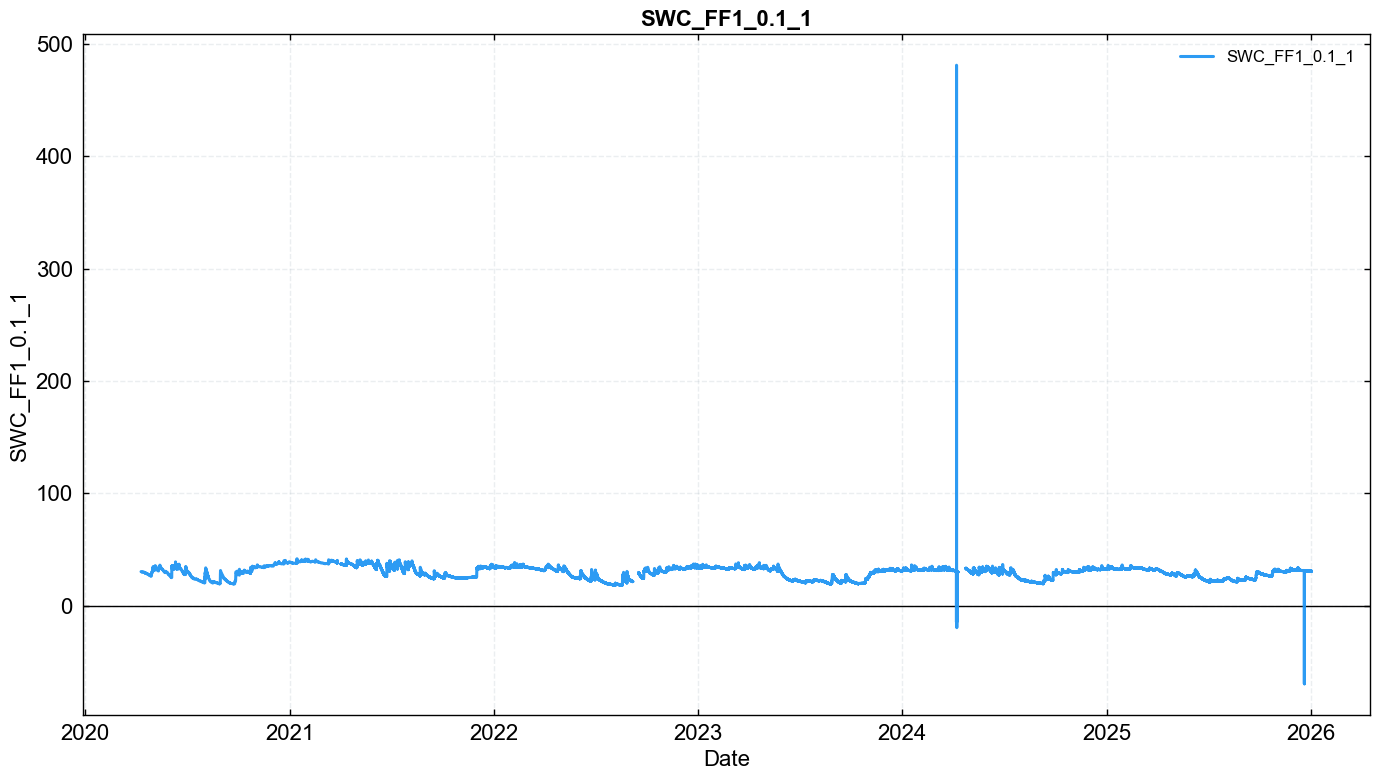

In [24]:
mscr = dv.qaqc.StepwiseMeteoScreeningDb(
    site=SITE,
    data_detailed=data_detailed,
    fields=FIELDS,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
)
mscr.showplot_orig()

## 🔍 Outlier detection
Run a test → inspect its preview → commit with `mscr.addflag()`. Only the committed flag of the **most recent** test is added. Skip any test a variable does not need.

**What soil water content needs, and what it does not.** The series is smooth, strongly autocorrelated, and seasonally non-stationary: it ranges over more than 20 percentage points between a wet winter and a dry August, and the wet and dry extremes are the most interesting values in it, not the least trustworthy. Two consequences run through this whole section:

- **Never split day and night.** Every test below is run with `separate_daytime_nighttime=False`. Soil moisture has no meaningful diurnal cycle at these depths, so a day/night split would only halve the sample of each threshold.
- **Distribution-wide tests do not belong here.** A z-score over the whole record measures how far a value sits from the multi-year mean, which for this variable is a statement about the season, not about data quality. Those tests are listed further down, switched off, with the reasoning.

What is actually needed is short: the failed-read sentinels and the one +481% read (**absolute limits**), and the **missing-values** flag. This depth has **no documented fault**, so no manual-removal window is used. No spike test is committed — see *No spike test is used* below for the measurement that settles it.

In [25]:
mscr.start_outlier_detection()

> Starting step-wise outlier detection for variable SWC_FF1_0.1_1 ...

Plot the current cleaned data at any point during detection:

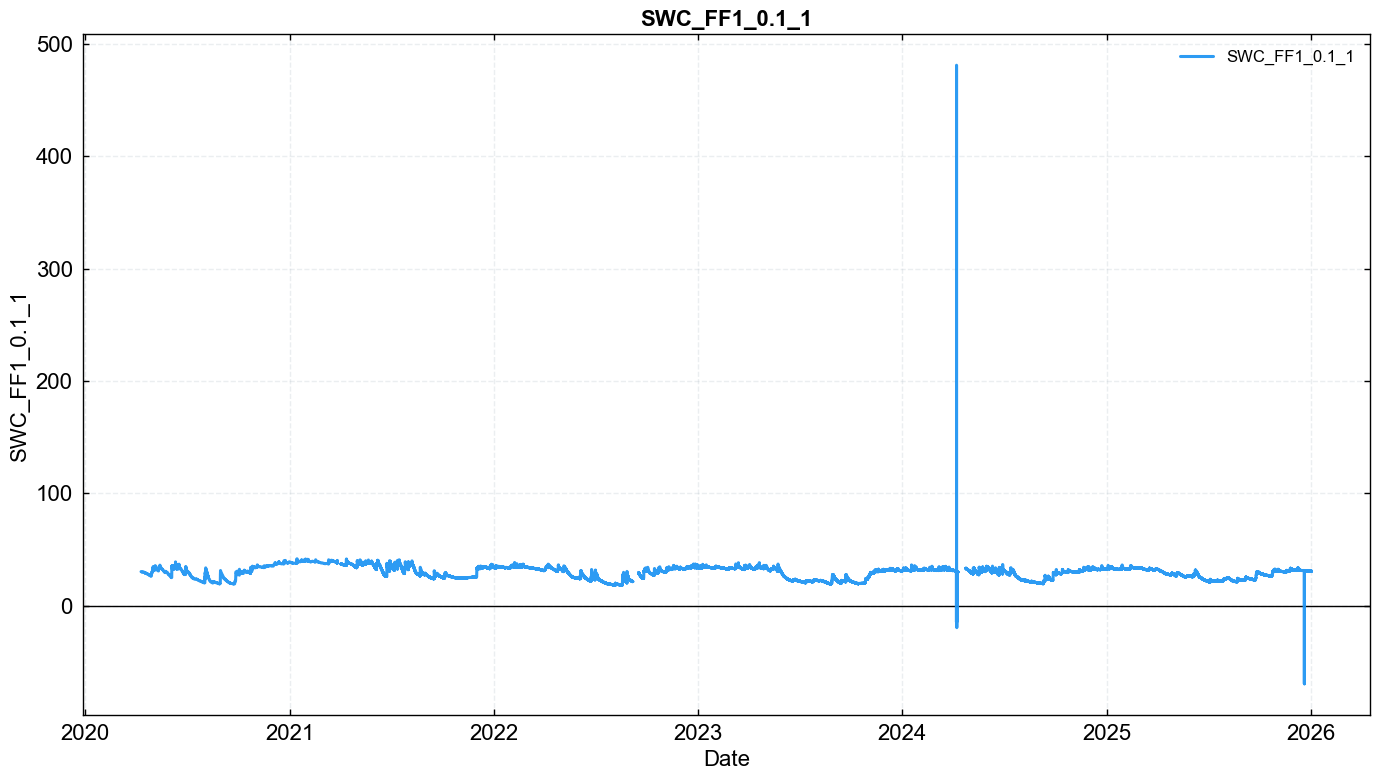

In [26]:
for key, val in mscr.outlier_detection.items():
    val.showplot_cleaned(interactive=False)

### Manual removal
Flag specific timestamps or time ranges for removal — known sensor failures, maintenance windows, etc. Give `[start, stop]` pairs and/or single timestamps.

In [27]:
if SHOW_PARAM_HELP:
    help(dv.outliers.ManualRemoval)

In [28]:
# Windows for THIS depth (10 cm). Re-derived from this sensor's own evidence.
#
# There are NONE. Every artefact at 0.1 m is caught by a physical rule and needs no
# manual window:
#   - the 27 failed-read sentinels and the single +481.04% read are removed by absolute
#     limits (or dropped earlier with the April 2024 frequency groups);
#   - every coverage gap is already missing and needs no removal;
#   - the rolling-agreement scan finds NO decoupling here (rolling r stays >= 0.30 in every
#     window, with 0.05's Aug-Oct 2020 fault masked out of the profile mean).
#
# The one thing that IS documented and deliberately NOT removed is the muted wetting response
# of 2023 and 2025 (the sandwich scan above: 5 and 7 events where 0.05 and 0.2 both wet up by
# 5-7% VWC and this probe did not). It is left in because it is EPISODIC, not a stretch: many
# events inside the same months respond normally (2025-06-04 ratio 1.06, 06-07 1.40, 09-22
# 0.65, 09-23 1.44, 09-24 4.12), June 2025 is normal, and the probe recovers fully each autumn
# and behaves normally in 2020/2021/2022/2024. The values are also not WRONG in level - only
# the amplitude of large wetting fronts is muted - so a window would delete about five months
# of mostly-good data to suppress seven events. See the closing note "Known limitation".
# The 0.05 decoupling window ['2020-08-01','2020-10-24'] belonged to the 5 cm probe alone
# and is deliberately NOT carried over here.
#
# Boundaries (were any needed) carry slack because screening runs on TIMESTAMP_MID while the
# cross-check above is on TIMESTAMP_END.
REMOVE_DATES = [
]
if REMOVE_DATES:
    mscr.flag_manualremoval_test(remove_dates=REMOVE_DATES, showplot=True, verbose=True)
else:
    print('No manual removal windows for this depth - skip the addflag cell below.')

No manual removal windows for this depth - skip the addflag cell below.


In [29]:
if REMOVE_DATES:
    mscr.addflag()

### Absolute limits
Flags values outside a fixed physical range `[minval, maxval]`. This is the workhorse test for soil water content — and at this depth it is essentially the *only* test that removes anything. Every artefact in this record is either a failed sensor read (a fixed negative sentinel) or the single corrupt **+481.04%** read, and all of them land outside `[0, 60]`.

In [30]:
if SHOW_PARAM_HELP:
    help(dv.outliers.AbsoluteLimits)

> running AbsoluteLimits ...

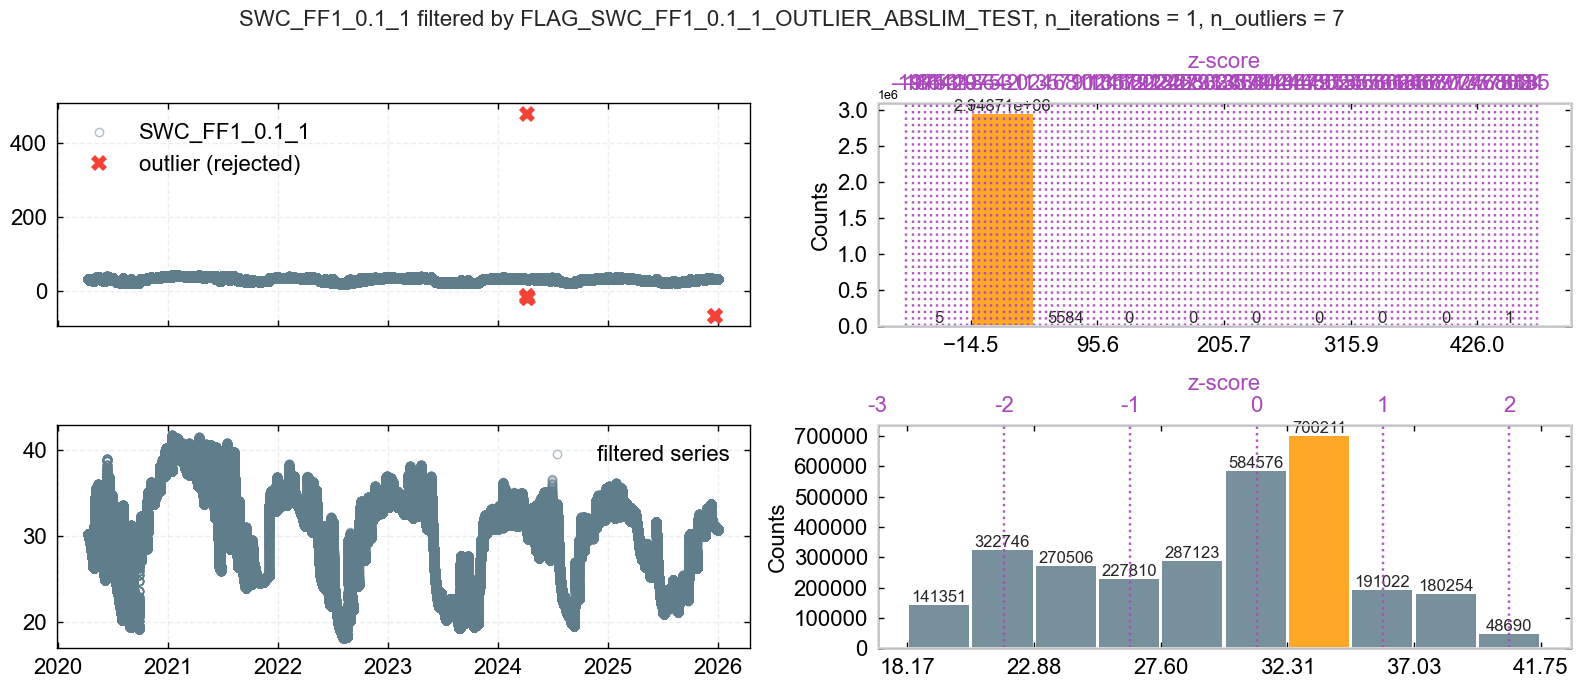

In [31]:
# Volumetric water content in %, so 0 is the hard physical floor. At this depth the UPPER
# limit does real work too: a single corrupt read of +481.04% on 2024-04-06 18:29 is the
# only value in the whole five-sensor profile above 60, and only maxval catches it. A failed
# SDI-12 read instead enters the record as that sensor's calibration polynomial evaluated at
# zero response, a fixed negative value per sensor (-14.2, -19.6, -69.6 ...) - the floor of 0
# catches those. Of the 28 out-of-range records only 7 reach this test; the other 21 sit in
# the stray 2/3/5/6-minute frequency groups of April 2024 and are dropped by diive first.
mscr.flag_outliers_abslim_test(minval=SWC_MIN, maxval=SWC_MAX, showplot=True, verbose=True)

In [32]:
mscr.addflag()

> ++Added flag column FLAG_SWC_FF1_0.1_1_OUTLIER_ABSLIM_TEST to flag data

### No spike test is used, and the Hampel filter must not be

Every remaining template test (Hampel, z-score, rolling z-score, local SD, increments z-score, local outlier factor, trim low) is **left switched off**. For the Hampel filter that is a measured decision, not a matter of taste. The table below is Hampel run **after** absolute limits on this depth, with the current (fixed) diive, counted **per era**:

| Hampel call | flagged in the 10MIN era | flagged in the 1MIN era | total |
|---|---|---|---|
| `use_differencing=True, n_sigma=8` | 4 (0.001%) | 173 (0.007%) | **177** |
| `use_differencing=True, n_sigma=30` | 0 | 19 | 19 |
| `use_differencing=True, n_sigma=100` | 0 | 3 | 3 |
| `use_differencing=False, n_sigma=8` | 10 147 (2.01%) | 13 983 (0.56%) | 24 130 |

> **On the diive version.** With the pre-fix diive the differenced Hampel mass-rejected the back-filled 10MIN era (it removed 19.4% of it at 0.05 m, at any `n_sigma`), because the rolling MAD of a mostly-constant series is zero and the detection band collapsed. The fix leaves records unflagged where the MAD is exactly zero and no longer differences across gaps, and it works: at 10 cm the differenced filter now touches just **4 records in the 10MIN era**, not tens of thousands. So the table above is the **working** filter, not the broken one.

**And the working filter still removes real soil moisture — which is the whole reason no spike test is committed.** Run after absolute limits, `use_differencing=True, n_sigma=8` flags 177 records, and **all twelve of the largest genuine minute-to-minute jumps in the record are among them**. Those jumps are wetting fronts, the most physically real feature in the series:

- 2021-07-26 17:24, 33.3 → 36.5% (14.8 mm that day) — still up six hours later;
- 2024-06-28 04:58, 30.9 → 34.1% (24.8 mm that day) — sustained;
- 2022-07-03 22:12 and 2021-06-23 20:03 (40.6 mm) — likewise.

The 99.99th percentile of minute-to-minute change is only **0.22% /min**; the fronts are fifteen times that and sustained for hours, while the largest genuine *drops* are barely −0.5% /min (wetting is fast, drying is slow — a symmetric spike filter cannot tell a fast front from a spike). The removals concentrate exactly where the real signal is: **47% of them fall on days with > 5 mm of rain, against 19% of all days**. The non-differenced Hampel is worse still, taking 24 130 records (2% of the back-filled era). Any filter tuned tightly enough to fire here removes the fronts.

The others, for the record: **z-score over the whole record** measures distance from the multi-year mean, which for this variable *is* the season — a wet February and a dry August sit at opposite ends of a 20-point range and both are correct. **Rolling z-score / local SD** fight the same physics. **Increments z-score** degenerates in the back-filled era exactly as the differenced Hampel used to. **Local outlier factor** is far too slow on 1MIN data. **Trim low** removes a fixed share of low values by construction.

So screening here is: **absolute limits** (the 7 failed reads and the one +481% read that reach the test) + **missing values**. There is no documented fault at this depth, so — unlike at 5 cm — there is not even a manual-removal window.

One practical warning for any test you do try: differencing-based tests compute their differences **after dropping missing records**, so the records flanking every gap are compared across the gap and look like spikes. This record has a 14-day gap in April 2024 and a 10-day one in September 2022.

If you want to try one anyway, the calls are below. Run it, look at the preview, check what it does to the 2020-2021 era specifically, and only `mscr.addflag()` if it is genuinely removing artefacts.

In [33]:
# Optional, all off by default - read the note above before enabling any of these,
# and check the flagged count per era rather than the total.
# mscr.flag_outliers_hampel_test(window_length=60 * 24, n_sigma=8, use_differencing=False,
#                                separate_daytime_nighttime=False,
#                                repeat=False, showplot=True, verbose=3)
# mscr.flag_outliers_zscore_test(thres_zscore=4.5, separate_daytime_nighttime=False,
#                                repeat=True, showplot=True, verbose=True)
# mscr.flag_outliers_zscore_rolling_test(thres_zscore=4.5, winsize=60 * 24 * 7,
#                                        repeat=True, showplot=True, verbose=True)
# mscr.flag_outliers_localsd_test(n_sd=7, winsize=60 * 24 * 7, constant_sd=False,
#                                 separate_daytime_nighttime=False,
#                                 repeat=False, showplot=True, verbose=True)
# mscr.flag_outliers_increments_zcore_test(thres_zscore=40, repeat=True, showplot=True, verbose=True)
# mscr.addflag()

### Missing values
Not an outlier test — flags missing records so they are counted in the overall `QCF`.

In [34]:
mscr.flag_missingvals_test(verbose=True)

> running MissingValues ...

> MISSING VALUES TEST: Generated new flag variable FLAG_SWC_FF1_0.1_1_MISSING_TEST, newly 
calculated from variable SWC_FF1_0.1_1, with flag 0 (good values) where SWC_FF1_0.1_1 is available, 
flag 2 (bad values) where SWC_FF1_0.1_1 is missing.

### Overall quality flag QCF
Aggregate all committed test flags into one overall flag `QCF` (0 = good, 1 = marginal, 2 = bad) and filter the series. Required before corrections and resampling.

In [35]:
mscr.finalize_outlier_detection()

#### Reports

In [36]:
mscr.report_outlier_detection_qcf_evolution()

====================================================================================================
====================

QCF EVOLUTION: SEQUENTIAL TEST APPLICATION

====================================================================================================
====================

Shows how QCF flag distribution changes as tests are applied sequentially

Target variable: SWC_FF1_0.1_1

...

(count)      (count)                          
0/1/2

----------------------------------------------------------------------------------------------------
--------------------

1     SWC_FF1_0.1_1_MISSING                  0        2954296      0            100.00    0.00      
2954296/0/0

2     SWC_FF1_0.1_1_OUTLIER_ABSLIM           7        2954289      7            100.00    0.00      
2954289/0/7

====================================================================================================
====================

In [37]:
mscr.report_outlier_detection_qcf_flags()

════════════════════════════════════════════════════════════════════════════════════════════════════

INDIVIDUAL TEST FLAG STATISTICS: SWC_FF1_0.1_1

════════════════════════════════════════════════════════════════════════════════════════════════════

Total test flags: 2

┌─ REPORT 1A: ALL RECORDS (INCLUDING MISSING VALUES)

...

├─ SWC_FF1_0.1_1_OUTLIER_ABSLIM

│  Period          │ Pass (0)        │ Warn (1)        │ Fail (2)        │ Missing

│  -------------------------------------------------------------------------------------

│  OVERALL         │ 2954289 (100.0%) │     0 (  0.0%)  │     7 (  0.0%)  │    0 (  0.0%)

════════════════════════════════════════════════════════════════════════════════════════════════════

In [38]:
mscr.report_outlier_detection_qcf_series()

======================================================================

QCF QUALITY CONTROL REPORT: SWC_FF1_0.1_1

======================================================================

[1] TIME PERIOD

Start:  2020-04-10 14:50

...

[4] DATA LOSS ANALYSIS

Records retained after QC: 2954289/2954296 (100.00%)

Data loss from QC:         7/2954296 (0.00%)

Final data coverage:       2954289/3011590 (98.10% of potential)

======================================================================

#### Plots

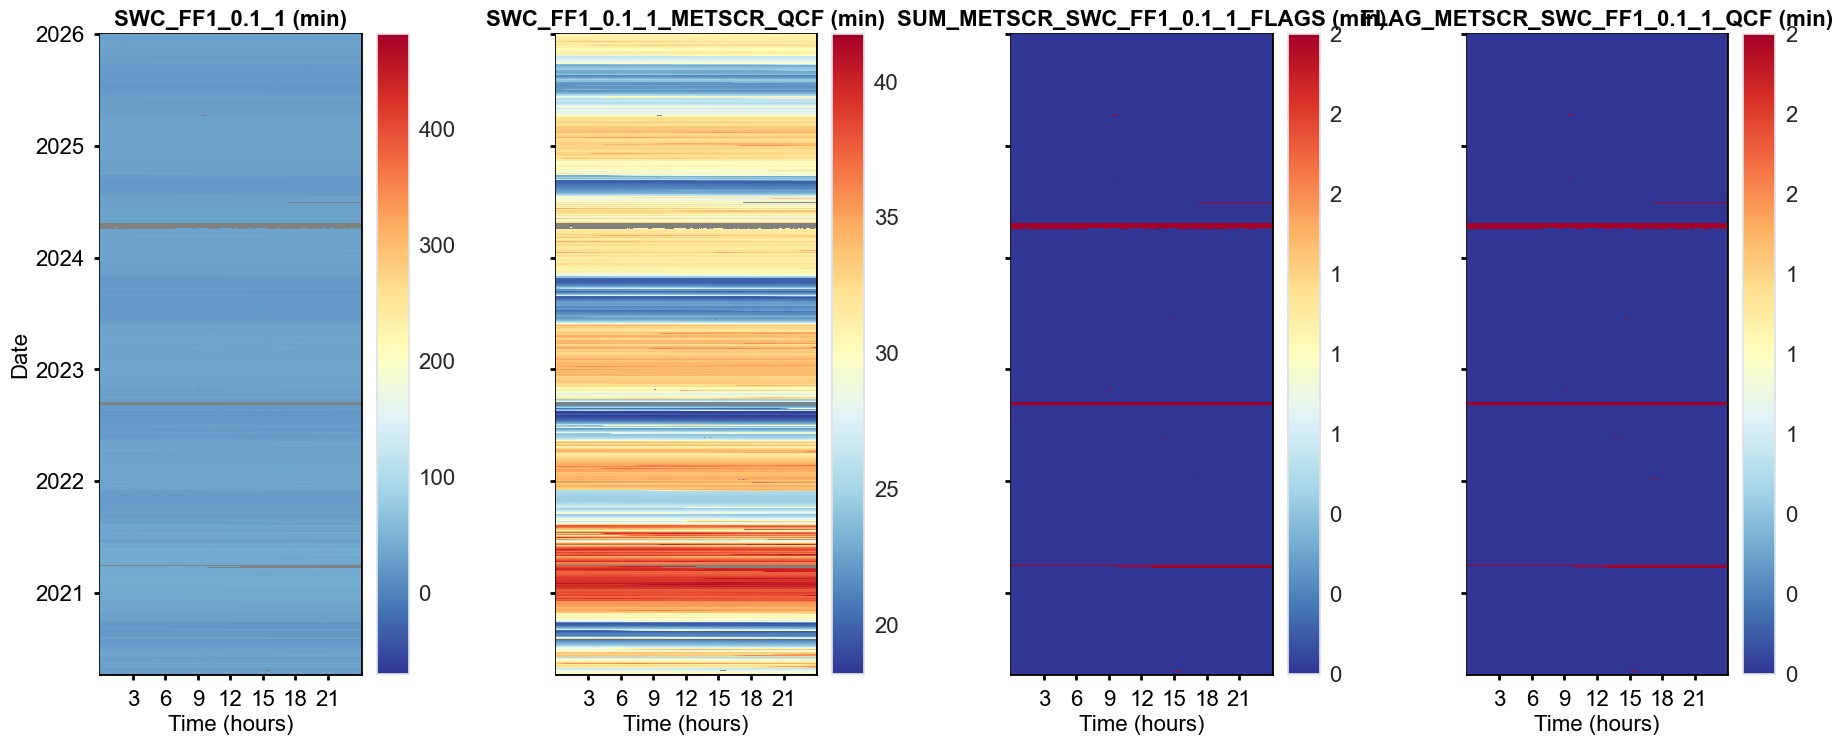

In [39]:
mscr.showplot_outlier_detection_qcf_heatmaps()
# mscr.showplot_outlier_detection_qcf_timeseries()

## 🔧 Corrections
Applied to the high-res, QCF-filtered data. **None of them apply to soil water content**, and all calls below stay commented out.

The corrections diive offers are offset removals for radiation and relative humidity, threshold clipping, and setting ranges to a constant — every one of them writes a value the sensor did not measure. For this variable there is nothing to correct *within* the series: a probe reading too high or too low is a calibration matter (soil-specific permittivity calibration), which cannot be fixed after the fact from the series itself, and this depth has no decoupling fault at all — the only artefacts are the out-of-range reads, already removed by absolute limits.

> ⚠️ In particular, do **not** clip to a minimum: the failed reads are already gone via absolute limits, and clipping would replace a missing measurement with a fabricated 0% — which reads as "bone dry soil" downstream.

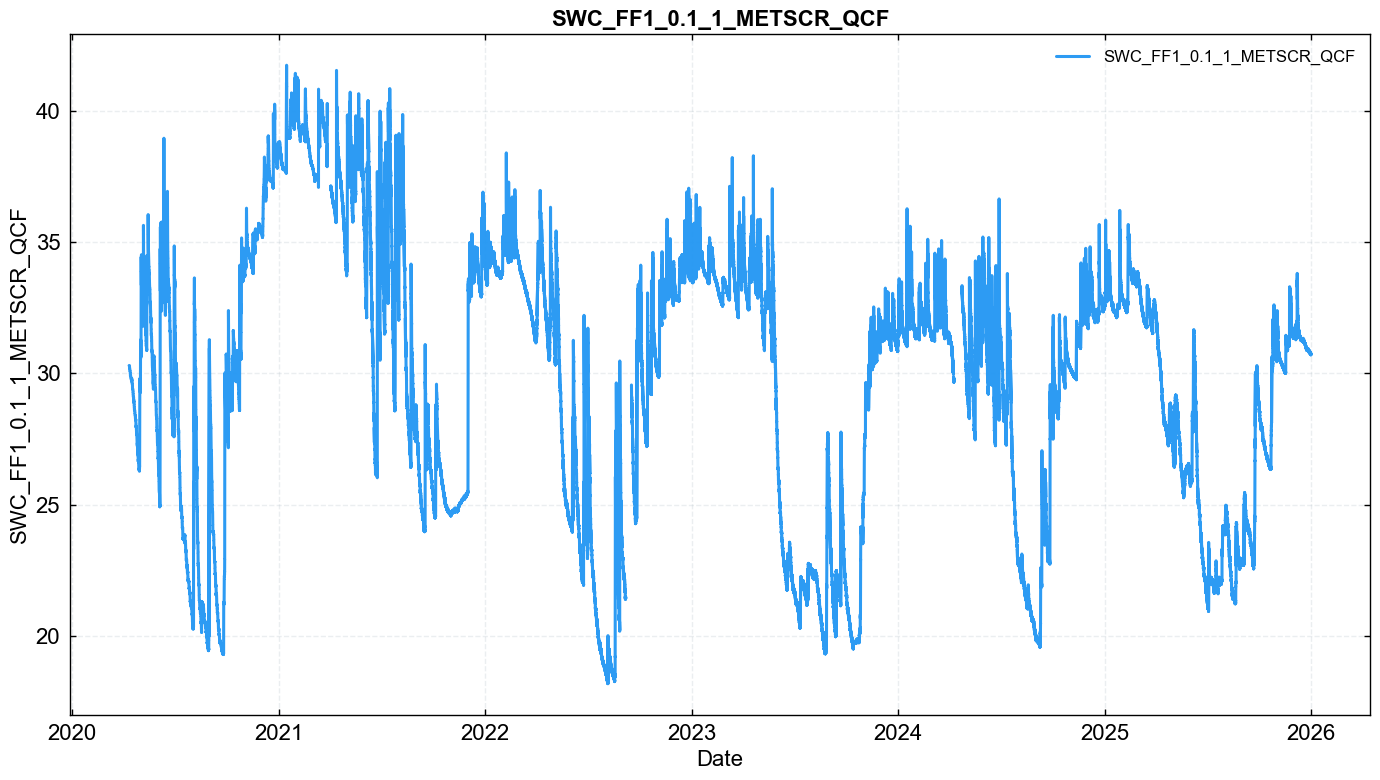

In [40]:
mscr.showplot_cleaned()

Inspect the most frequent values first (read-only, safe to run). For soil water content there should be **no** dominant repeated value: a value appearing thousands of times in the 1MIN era would mean a stuck sensor. Frequent repeats *are* expected in the 2020-2021 part, where each 10MIN reading was back-filled across ten 1MIN slots.

In [41]:
for ff in mscr.fields:
    vc = mscr.series_hires_cleaned[ff].value_counts()
    print(f'--- {ff} (top 20 of {mscr.series_hires_cleaned[ff].count()} records) ---')
    print(vc.head(20))

--- SWC_FF1_0.1_1 (top 20 of 2954289 records) ---
SWC_FF1_0.1_1_METSCR_QCF
29.8    2022
30.1    1180
28.4    1130
29.7    1120
29.9    1100
29.6    1060
30.3    1048
28.9    1020
28.6    1010
29.1     940
29.4     900
30.2     530
29.3     453
30.0     420
28.7     400
28.5     360
29.2     350
28.8     313
29.0     290
29.5     280
Name: count, dtype: int64


In [42]:
# All commented out on purpose - none of these apply to soil water content.
# mscr.correction_setto_max_threshold(threshold=60)
# mscr.correction_setto_min_threshold(threshold=0)
# mscr.correction_setto_value(dates=[['2022-04-01', '2022-04-05']], value=0, verbose=1)
# mscr.correction_set_exact_value_to_missing(values=[0])
# mscr.showplot_cleaned(interactive=False)

## 🔁 Resampling

### Resample to 30MIN
Resample the screened high-res series to `RESAMPLING_FREQ`. The output timestamp is `TIMESTAMP_END` again (see *Timestamp convention*), ready for upload.

> running resample_series_to_freq ...

> Resampling data from min to 30min frequency ...

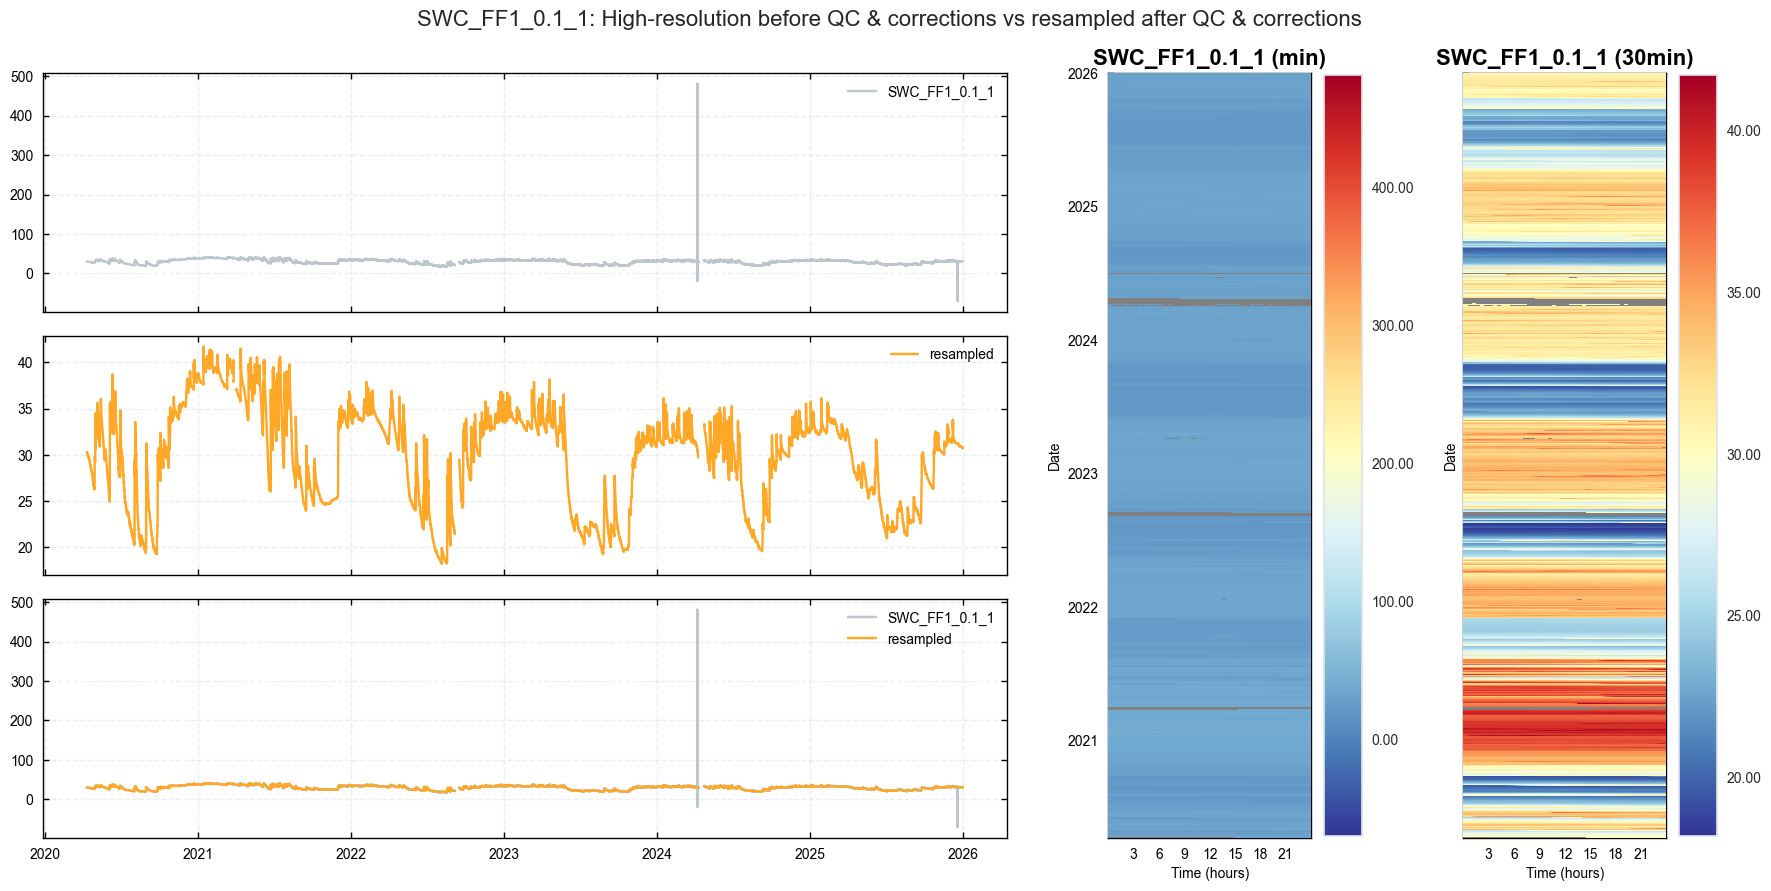

In [43]:
# mincounts_perc stays at the template default of .25, the opposite choice from the
# precipitation notebook. A 30MIN *mean* of a smooth state variable is well estimated
# from a quarter of the records, whereas a *sum* built from a quarter of the records
# under-reports by construction. Requiring near-complete coverage here would throw
# away good half-hours during the April 2024 bus trouble for no gain in accuracy.
mscr.resample(to_freqstr=RESAMPLING_FREQ, agg=RESAMPLING_AGG, mincounts_perc=.25)
mscr.showplot_resampled()

### Check the resampled time resolution

In [44]:
for v in mscr.resampled_detailed.keys():
    freq = dv.times.DetectFrequency(index=mscr.resampled_detailed[v].index, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: {freq}')

> Detect frequency: 30min (all methods agree)

PASSED - SWC_FF1_0.1_1: 30min


### Re-check the screened product against the profile
The same comparison as before screening, now on the resampled 30MIN product. Screening should leave the agreement with the rest of the profile **no worse** than it was — if the correlation drops, a test removed real soil moisture rather than an artefact. Unlike at 5 cm there is no removal window to improve on here: `REMOVE_DATES` is empty and the only value-removing test is absolute limits, which reaches just 7 of the 28 out-of-range minutes (the other 21 never enter screening at all). So the agreement should come back **unchanged**; a drop would mean absolute limits had bitten into real data. The companion mean used here has the 5 cm sensor's 2020 decoupling masked out, as above.

In [45]:
_screened = mscr.resampled_detailed[FIELD][FIELD]

_before = prof_masked.resample('D').mean()
_after = _before.copy()
_after[FIELD] = _screened.resample('D').mean()

r_before = _before[FIELD].diff().corr(_before[COMPANIONS].mean(axis=1).diff())
r_after = _after[FIELD].diff().corr(_after[COMPANIONS].mean(axis=1).diff())
n_before = prof[FIELD].notna().sum()
n_after = _screened.notna().sum()

print(f'{"":18s} {"n 30MIN":>9s} {"r(increments)":>15s} {"mean [%]":>10s}')
print(f'{"before screening":18s} {n_before:9d} {r_before:15.3f} {prof[FIELD].mean():10.2f}')
print(f'{"after screening":18s} {n_after:9d} {r_after:15.3f} {_screened.mean():10.2f}')
print(f'{"removed":18s} {n_before - n_after:9d} '
      f'({(1 - n_after / n_before) * 100:.2f}% of the half-hours that had a value)')

if r_after < r_before - 0.01:
    print('\n(!) WARNING - agreement with the profile got worse. A test may have removed real data.')
else:
    print('\nOK - screening did not degrade agreement with the rest of the profile.')

                     n 30MIN   r(increments)   mean [%]
before screening       98583           0.836      29.77
after screening        98539           0.836      29.77
removed                   44 (0.04% of the half-hours that had a value)

OK - screening did not degrade agreement with the rest of the profile.


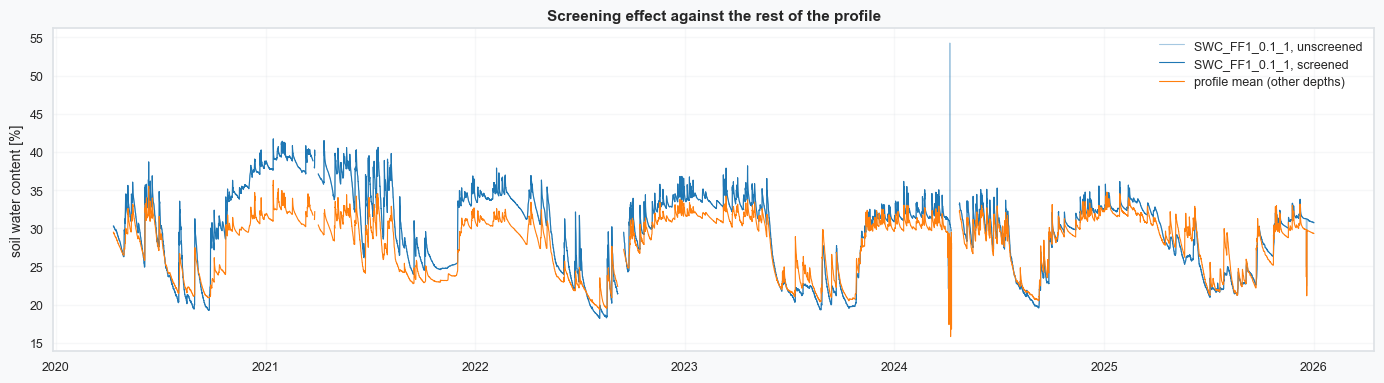

In [46]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(prof.index, prof[FIELD], label=f'{FIELD}, unscreened', color='tab:blue', alpha=.4, lw=.8)
ax.plot(_screened.index, _screened, label=f'{FIELD}, screened', color='tab:blue', lw=.8)
ax.plot(prof.index, prof[COMPANIONS].mean(axis=1), label='profile mean (other depths)',
        color='tab:orange', lw=.8)
ax.set_ylabel('soil water content [%]')
ax.set_title('Screening effect against the rest of the profile')
ax.legend()
plt.tight_layout()
plt.show()

### 🧪 Screening invariants
The re-check above is a diagnostic: a number you look at and judge. The two lines below are **invariants — asserted, not eyeballed**, so a re-run that quietly breaks one stops the notebook instead of uploading a record nobody looked at closely enough.

`REMOVE_DATES` is empty at this depth, so absolute limits is the **only** value-removing test, and these two asserts therefore cover *everything* screening took out of this record: no record counted as out-of-range is in fact inside `[SWC_MIN, SWC_MAX]`, and no out-of-range value survived into the cleaned high-res series.

The full two-direction audit (did every removal earn its place, and is the real signal still there?) lives in `SWC_FF1_0.05_1` — the only depth with a manual removal window, where a human judgement call needs policing on every run — and in `SWC_FF1_0.2_1`. Here the profile re-check above plus these two asserts are enough.

**If this depth ever gains a `REMOVE_DATES` window, port that audit over.** A hand-picked window is a claim about the data that no physical rule checks, so from that moment on these two lines no longer describe everything screening removed.

In [47]:
# Invariants, not diagnostics: the two things absolute limits must be true of, asserted rather
# than eyeballed. REMOVE_DATES is empty at this depth, so absolute limits is the only
# value-removing test and these two lines cover everything screening took out.
_raw_hires = data_detailed[FIELD][FIELD].dropna()
_oor = _raw_hires[(_raw_hires < SWC_MIN) | (_raw_hires > SWC_MAX)]
_surv = mscr.series_hires_cleaned[FIELD].dropna()

assert ((_oor < SWC_MIN) | (_oor > SWC_MAX)).all(), \
    '(!) a record counted as out-of-range is actually inside the physical range'
assert _surv.between(SWC_MIN, SWC_MAX).all(), '(!) an out-of-range value survived screening'

print(f'out-of-range records in the raw series: {len(_oor)}'
      + (f'  ({_oor.min():.2f} .. {_oor.max():.2f} % VWC)' if len(_oor) else ''))
print(f'surviving hi-res values, all inside [{SWC_MIN}, {SWC_MAX}]: '
      f'{_surv.min():.2f} .. {_surv.max():.2f} % VWC  -> PASSED')

out-of-range records in the raw series: 28  (-69.56 .. 481.04 % VWC)
surviving hi-res values, all inside [0, 60]: 18.17 .. 41.75 % VWC  -> PASSED


## ⬆️ Upload data to database

**Re-uploading overwrites the same variant — safe to re-run.** With `delete_from_db_before_upload=True` (below), the upload first *deletes*, then writes. The delete is scoped to the exact match `_measurement` + `varname` + `data_version` (`meteoscreening_diive`) over the uploaded time range, so re-screening a period replaces only its previous screened result. It never touches the raw data (different `data_version`, and a different `_raw` bucket), other variables, or other data versions. The delete-first step (rather than a plain overwrite) matters because InfluxDB keys a point by its full tag set: if a tag changed between runs (e.g. `units`, `gain`, `offset`), a plain write would leave the old point as a **duplicate** — the delete removes it regardless of tags.

Only the target variable is uploaded. The companion depths were read read-only from the shared raw-profile file for the cross-check, and each has its own notebook.

In [48]:
print(f'Uploading to bucket {BUCKET_PROCESSED}')
for v in mscr.resampled_detailed.keys():
    dbc.upload_singlevar(
        to_bucket=BUCKET_PROCESSED,
        to_measurement=assigned_measurements[v],
        var_df=mscr.resampled_detailed[v],
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        delete_from_db_before_upload=True,
    )

Uploading to bucket ch-lae_processed


> Deleted variables ['SWC_FF1_0.1_1'] between 2020-04-10T15:00:00+01:00 and 
2026-01-01T00:00:00+01:00 from measurements ['SWC'] in bucket ch-lae_processed.

> Connecting to database ...

> --> UPLOAD TO DATABASE BUCKET ch-lae_processed:  ['SWC_FF1_0.1_1']

v Upload finished.

### Verify upload
Download the just-uploaded data back and confirm the time resolution and timestamps. The offset is the same `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the timestamps below should again be local `TIMESTAMP_END` — matching what you screened.

In [49]:
# Fresh variable names so the screened originals (data_detailed etc.) are not overwritten:
check_simple, check_detailed, check_measurements = dbc.download(
    bucket=BUCKET_PROCESSED,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_diive',
)
check_simple

> DOWNLOADING from bucket ch-lae_processed: variables ['SWC_FF1_0.1_1'] from measurements ['SWC'],
data version ['meteoscreening_diive'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone
offset to UTC 1)

> Downloaded data for 1 variables:

,SWC_FF1_0.1_1
TIMESTAMP_END,
2020-04-10 15:00:00,30.300000
2020-04-10 15:30:00,30.300000
2020-04-10 16:00:00,30.300000
2020-04-10 16:30:00,30.300000
2020-04-10 17:00:00,30.300000
...,...
2025-12-31 22:00:00,30.736580
2025-12-31 22:30:00,30.735927
2025-12-31 23:00:00,30.733229


In [50]:
for v in check_detailed.keys():
    idx = check_detailed[v].index
    freq = dv.times.DetectFrequency(index=idx, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: freq={freq}, first={idx[0]}, last={idx[-1]}')

> Detect frequency: 30min (timedelta, 100% match)

PASSED - SWC_FF1_0.1_1: freq=30min, first=2020-04-10 15:00:00, last=2026-01-01 00:00:00


## ✅ End of notebook

In [51]:
_end = datetime.now()
print(f"Finished: {_end.strftime('%Y-%m-%d %H:%M:%S')}  "
      f"(runtime {str(_end - NOTEBOOK_START).split('.')[0]})")

Finished: 2026-07-22 15:58:11  (runtime 0:07:19)


***
### \U0001F4DD Notes for this variable
- **Mean, not sum.** `RESAMPLING_AGG = 'mean'` — soil water content is a state, not a flux.
- **Units are volumetric %,** stored with `gain = 100` on a raw `m^3/m^3` reading. The database unit tag says `%`; the magnitudes (18-42) agree, and the export is checked against it above. (The one exception, +481.04%, is `4.81 m^3/m^3` before gain — a corrupt read, removed by absolute limits.)
- **Sensor history.** The FF1 profile is five **TEROS 12** probes installed on 19 Mar 2020 (the old M5/EC-20 sensors were removed and trashed the same day) and first logged on 10 Apr 2020, which is where this record begins. The logger box was rebuilt on 24-26 Mar 2021, which changed the resolution from 10MIN to 1MIN but not the sensors. **This notebook screens the TEROS era only, by choice — the name is not empty before it.** `SWC_FF1_0.1_1` also carries 239,458 30MIN records under `data_version='meteoscreening_mst'`, 2004-09-07 to 2018-12-31, where the old probe at this depth stopped (the earliest of the four to go). That record is the old EC-20 (*M5*) profile **written under the FF1 names** by the MeteoScreeningTool, not an earlier stretch of this sensor — proven at 0.2 m, the only depth where the two coexist, where the mst series and raw `SWC_M5_0.2_1` have the same mean (21.8320) and r = 0.998. The raw `SWC_M5_*` names exist only in `ch-lae_raw`, and only over 2020-01-01 → 2020-04-10. The two eras share no timestamp and the level steps by ≈ +10.1 % VWC here, so joining them is a splice of two instruments and belongs downstream: `30_PRODUCTS/09_METEO_SWC_FF1_2004-2025.ipynb` does it behind a `FLAG_..._SOURCE` flag and exports a `_HOMOGENIZED` column as well. The pre-2020 record is not lost, just handled there.
- **Two raw time resolutions** (10MIN then 1MIN) — see the dedicated section above.
- **The first 11 days are coarse.** From 2020-04-10 to 2020-04-21 values arrive in steps of 0.1% VWC; a logger software change on 21 Apr 2020 moved them to full float precision. The values are usable throughout, but expect the flat-run scan to fire there — at this depth one hold reaches 26 h (2020-04-13 → 04-14).
- **A failed sensor read is a number, not a gap.** The CR1000 firmware predates SDI-12 NaN support, so a failed read lands as a fixed negative value (this sensor: −14.2, −19.1 … −69.56). Absolute limits, not the missing-values flag, catches them, and a floor of `0` is not optional. Of the 28 out-of-range records only **7** reach that test; the other **21** are discarded earlier, with the stray frequency groups of April 2024. None survives into the product.
- **The upper limit does real work here.** Unique among the five depths, 0.1 m holds one corrupt **+481.04%** read (2024-04-06 18:29, inside the April 2024 bus failure). It is the only value in the profile above 60, so `maxval=60` — decorative at the other depths — is what removes it. Left in, it inflates a single 30MIN mean to 54.26%.
- **No decoupling fault, and no manual removal.** The rolling-agreement check finds nothing at this depth (rolling r ≥ 0.30 throughout), so `REMOVE_DATES` is **empty**. This is the main way 0.1 differs from 0.05.
- **The profile is the reference, and it is not a replicate set.** The depths differ in level and amplitude by design; only the *ordering* of the response is physically enforced (shallow wets first). Nothing from the companion depths is written into this series or uploaded. The 5 cm decoupled window (Aug-Oct 2020) is masked out of the companion mean here, because the cached companions are raw.
- **Not a gap-filling source.** The companion depths and the precipitation product are used for comparison only.

***
### ✅ Why this depth needs no manual removal

Unlike 5 cm, `SWC_FF1_0.1_1` carries **no continuous decoupling**. The rolling 30-day agreement of its
daily increments with the rest of the profile stays at or above 0.30 in every window of all six years
(yearly minima 0.30, 0.34, 0.54, 0.35, 0.60, 0.33). Everything *removed* at this depth is removed by a
**physical rule** — the out-of-range reads via absolute limits, or the earlier frequency-group drop.

It does, however, carry a real and **deliberately kept** limitation: an episodic muted wetting response
in the dry seasons of 2023 and 2025, documented in *Known limitation* below. That is a judgement call,
not an oversight, and the numbers behind it are in the sandwich-scan cell so it can be re-argued.

**The re-check after screening confirms it**, in both directions:

- *Is everything removed genuinely bad?* Nothing leaves this record without a test asking for
  it: `REMOVE_DATES` is empty, so absolute limits is the only value-removing test, and every
  record it takes is genuinely outside `[0, 60]` — 27 fixed negative sentinels plus the one
  +481.04%.
- *Is everything real still there?* Agreement with the rest of the profile is **unchanged** by
  screening (increment correlation 0.836 → 0.836; half-hours carrying a value 98,583 →
  98,539), and the large wetting fronts are untouched — *No spike test is used* above
  measures what committing one would have cost them.

> Unlike `0.2`, this notebook carries no separate audit section counting surviving rain
> responses and checking whether a removed minute emptied its half hour. With an empty
> `REMOVE_DATES` and seven isolated minutes removed, the re-check is the whole check here —
> port that cell over if this depth ever gains a removal window.

### ⚠️ The one artefact worth naming: a corrupt +481% read

The single most unusual value in this record is **+481.04% VWC at 2024-04-06 18:29**, unique in the whole
five-sensor profile. It sits between two ordinary 30.5% readings a minute either side, inside the April
2024 SDI-12 bus failure. It is not a wetting front and not a sentinel — it is a one-off corrupt read, and
it is the reason the *upper* absolute limit matters at this depth. Removed by absolute limits; the 30MIN
mean of its half hour falls from 54.26 back to 30.55 once the raw minute is gone (18 of 19 records remain).

### \U0001F50E Fieldbook cross-check (GIN export `CH-LAE-laegeren-export_20260719.csv`)

The export is read in the *Adjudicate the candidates* cell above; this is the summary. There are 20 entries
filed at this depth's own location/device tag (`CH-LAE_FF1_0.1` / `CH-LAE_iSWC_FF1_0.1_1`) — all
profile-installation, logger-rebuild and later-incident entries, none flagging a soil fault during
2020-2025. Events that explain something in the data, none needing a removal beyond what the tests do:

| Data feature | Fieldbook entry |
|---|---|
| 0.1% value steps 2020-04-10 → 2020-04-21 and the 26 h identical-value hold | 2020-04-21, "New datalogger software with two byte precision for the soil profile measurement (Teros 12 and 21)" — full float precision after it |
| Failed reads stored as fixed negative numbers | 2020-04-10, the CR1000 firmware predates SDI-12 NaN support and was deliberately not updated ("thinking of the imminent system upgrade") |
| Gap 2021-03-24 → 2021-03-29 and the 10MIN → 1MIN change | FF1 logger box rebuilt, all components shut down 24 Mar, new CR1000 and program, data acquisition restarted 26 Mar |
| Gap 2022-09-06 → 2022-09-16 (10 d) | FF1 12 V DC-DC power supply failed; "power outage at the FF1", replaced 16 Sep |
| Gap 2023-06-15 (20 h) | "problem with the power at ch-lae … the ff1 is [affected]"; "FF1 is running again" 16 Jun |
| 2024-04-03 → 2024-04-23 (degraded logging, stray records, negative reads incl. the +481, then 14 d out) | the 0.3 m probe was failing and "caused an interruption of the SDI12 communication of all sensors at the same port"; unplugged 23 Apr, which is exactly when this record resumes |
| Negative reads on all five depths, 18-19 Dec 2025 | two remote logger-program uploads to the FF1 meteo logger on exactly those days ("Remotly uploaded new loggerprogram", then a windvane fix) |

**Unexplained:** two coverage gaps have no fieldbook entry within ±3 days — **2024-06-29 → 2024-07-01**
(44 h) and **2024-10-16** (8 h). The first is the same gap the precipitation notebook flagged, so it is a
station-wide outage, not a soil-sensor fault.

The 23 Oct 2025 wind storm (a beech onto the FF1 station) damaged only above-ground sensors; the buried
profile logged through it and all five depths wet up with the storm rain — no gap, no step at 10 cm.

### ⚠️ Known limitation: muted wetting response, dry seasons of 2023 and 2025

**This is kept in the product, not removed. Downstream users of 10 cm soil moisture in 2023 and 2025
should know that large wetting events are under-represented in those two summers.**

In 2023 (5 events) and 2025 (7 events) this probe responded far too weakly to rain **while the layers
directly above and below it both wet up strongly**. Since water cannot reach 20 cm without passing
10 cm, this is a property of the probe or of the flow path around it, not of the reference:

| event | 0.05 m | **0.1 m** | 0.2 m | ratio vs neighbours | rain |
|---|---|---|---|---|---|
| 2025-05-20 | +6.99 | **+0.08** | +5.71 | 0.01 | 18.5 mm |
| 2025-05-21 | +6.88 | **+0.75** | +5.48 | 0.12 | 10.3 mm |
| 2025-04-23 | +4.81 | **+0.57** | +2.75 | 0.15 | 13.4 mm |
| 2025-09-21 | +7.21 | **+1.66** | +6.93 | 0.23 | 14.0 mm |
| 2025-07-26/27/28 | +5.4/+6.1/+5.3 | **+1.5/+2.1/+1.7** | +6.6/+6.8/+4.9 | 0.25-0.32 | 11-25 mm |
| 2023-07-24/25/26 | +7.2/+7.2/+6.6 | **+1.2/+1.4/+1.3** | +5.9/+5.4/+5.1 | 0.19-0.22 | 14-18 mm |
| 2023-09-13 | +7.20 | **+2.28** | +7.52 | 0.31 | 41.7 mm |

(change in daily mean [% VWC] from the day before to the two days after)

**2025-05-20 is the sharpest case.** At hourly resolution, between 19:00 and 22:00 the 5 cm sensor rises
24.31 → 26.75 and the 20 cm sensor rises 28.58 → 34.30, while 10 cm goes 25.37 → 25.39. Saturation is
ruled out: the daily mean sat at 25.40% against an in-range record maximum of 41.75%.

**Why it is nevertheless kept:**

1. **It is episodic, not a stretch.** Unlike the 5 cm probe's 12-week continuous decoupling in 2020
   (ratio 0.04 at *every* event), this probe responds normally at many events inside the same months —
   2025-06-04 (1.06), 06-07 (1.40), 08-21 (0.70), 09-04 (0.74), 09-22 (0.65), 09-23 (1.44), 09-24 (4.12).
   June 2025 is entirely normal (amplitude ratio 0.83).
2. **It recurs and fully recovers.** The same signature appears in 2023 and is gone by that November;
   2020, 2021, 2022 and 2024 show **zero** such events. A recurring dry-season phenomenon that heals
   every autumn does not behave like a failing sensor.
3. **The values are not wrong in level,** only in wetting amplitude. The series stays in range, follows a
   coherent drying curve, and the rolling 30-day increment correlation never drops below 0.30.
4. **A window would be blunt and expensive.** Covering 2025-04-23 → 2025-09-21 alone would delete about
   five months (~7 200 half-hours) of largely good data to suppress seven events.

**The cause is not settled.** Two explanations fit equally well and this record cannot separate them:
*preferential / macropore bypass flow* routing water past a matrix-dominated 10 cm measurement volume in
dry soil (supported by 2025-08-28/29, where 0.05 and 0.1 are flat *together* and the deeper sensors rise),
or a *partial loss of probe-soil contact* in dry soil, with shrinkage gaps that close on rewetting. Both
are episodic, both are dry-season, both heal in autumn.

**The fieldbook is silent.** No entry touches the FF1 soil profile between the 0.3 m replacement of
4 Mar 2025 and the 23 Oct 2025 windstorm. The 2025-06-27 → 07-06 incident names `TS_FF1_02_1` — the soil
*temperature* at 0.2 m — not this sensor. The 23 Oct 2025 windstorm postdates the whole anomaly and
damaged only above-ground FF1 sensors; the 10 cm response is normal from October onward (ratios
0.63-1.15). As with the 5 cm fault, this rests on physical evidence alone.

### ♻️ Reusing this notebook for the other depths

This file is itself the 10 cm copy of the 5 cm pattern notebook. To screen another depth, copy the pattern
notebook (`SWC_FF1_0.05_1_2020-2025.ipynb`) to `SWC_FF1_<depth>_1_2020-2025.ipynb` and change **`DEPTH`** in
*User settings*; everything else is derived from it. Then:

1. **Re-run the cross-check and re-derive `REMOVE_DATES` and `CANDIDATES` from that depth's own scan
   output.** The 5 cm decoupling window belongs to the 5 cm probe alone; 10 cm needed no window at all.
   Where a companion depth was itself decoupled (5 cm, Aug-Oct 2020), mask that window out of the companion
   mean, as done here, because the cached companions are raw.
2. **Expect the rain-response test to weaken with depth,** and do not stop at the profile-mean ratio.
   A ratio near 0 is damning at 5 cm and unremarkable at 50 cm, and the mean can be dragged by a
   relocated or muted deep probe — so a low ratio alone convicts nobody. Use the **sandwich scan**
   instead: compare each depth against its two *immediate neighbours*, which is the only comparison
   physics actually constrains (water cannot skip a layer). At 10 cm that scan turned a ratio dip
   originally dismissed as a reference artefact into a real, documented finding.
3. **Two depths carry known faults, already in the fieldbook.** `0.3` failed in April 2024, was unplugged
   on 23 Apr 2024 and replaced on 4 Mar 2025 — but 40 cm down the slope, so its level differs by ~3% VWC:
   a sensor change inside one field name (its 2024 coverage here is only 27%). `0.2` has an incident logged
   27 Jun 2025 ("does not work regularly since 27.02"), closed 6 Jul 2025 — check 27 Feb → 6 Jul 2025 for
   that depth, and establish from the data whether it was the SWC or the co-located TS sensor.
4. **`[0, 60]` is physical and holds for every depth** — but note the upper bound is not decorative: at
   10 cm it removes the one +481% read. Check the value range printed by the cross-check first.
5. **If you add any outlier test, report its flagged count per era, never as a total.** Every depth has the
   same 10MIN-then-1MIN structure and the same trap. This notebook commits no spike test because, after
   absolute limits, every large jump left is a real wetting front.